In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pystout import pystout
from scipy.stats import ttest_ind
from itertools import combinations, product
from lifelines import CoxPHFitter

color_scheme = ["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"]

In [34]:
def set_plot_theme():
    # base seaborn theme & palette
    sns.set_theme(
        style="white",           # consistent with file_context_0
        palette=["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"],          # or your own list of colors
        font="serif",            # consistent with file_context_0
        font_scale=1.1
    )

    # tweak matplotlib rcParams you care about
    plt.rcParams.update({
        "text.usetex":       True,  # consistent with file_context_0
        "axes.titlesize":    16,
        "axes.labelsize":    14,
        "legend.frameon":    False,
        "figure.figsize":    (8, 5),
        "lines.linewidth":   2,
        "lines.markersize":  6,
        # …any other defaults…
    })

def finalize_plot(ax=None):
    if ax is None:
        ax = plt.gca()
    sns.despine(ax=ax)
    ax.figure.tight_layout()

In [35]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full_excluded.csv")

# Table Comparing Model to Data

In [36]:
plot_df = df[
    (df['participant_role'] == 'Buyer') & 
    (df["treatment"] == "T4")
].copy()

print(len(plot_df))

790


In [37]:
region_1 = plot_df[plot_df["valuation"] < 7.72]
print(len(region_1))
region_2 = plot_df[(plot_df["valuation"] >= 7.72) & (plot_df["valuation"] < 21.40)]
print(len(region_2))
region_3 = plot_df[plot_df["valuation"] >= 21.40]
print(len(region_3))

202
373
215


In [38]:
import scipy.stats as stats
region_1["deal_price"] = region_1["deal_price"].fillna(0)
trade_price_region_1 = region_1["deal_price"].mean()
std = region_1["deal_price"].std()
n = len(region_1)
ci = stats.t.interval(0.95, df=n-1, loc=trade_price_region_1, scale=std / np.sqrt(n))
print(f"Mean trade price: {trade_price_region_1:.2f}, 95% CI: ({ci[0]:.2f}, {ci[1]:.2f})")
print(region_1["bargaining_outcome"].value_counts(normalize=True))


Mean trade price: 0.39, 95% CI: (0.22, 0.55)
bargaining_outcome
Player                0.717822
Random_Termination    0.168317
acceptance            0.113861
Name: proportion, dtype: float64


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_18785/1385892372.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_1["deal_price"] = region_1["deal_price"].fillna(0)


In [39]:
import statsmodels.formula.api as smf
#region_2["deal_price"] = region_2["deal_price"].fillna(0)
model = smf.ols("deal_price ~ valuation", data=region_2).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             deal_price   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     66.03
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           4.81e-14
Time:                        09:41:58   Log-Likelihood:                -531.41
No. Observations:                 199   AIC:                             1067.
Df Residuals:                     197   BIC:                             1073.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5362      0.976      0.549      0.5

In [40]:
trade_price_region_3= region_3["deal_price"].mean(skipna=True)
std = region_3["deal_price"].std()
n = len(region_3)
ci = stats.t.interval(0.95, df=n-1, loc=trade_price_region_3, scale=std / np.sqrt(n))
print(f"Mean trade price: {trade_price_region_3:.2f}, 95% CI: ({ci[0]:.2f}, {ci[1]:.2f})")
print(region_3["bargaining_outcome"].value_counts(normalize=True))


Mean trade price: 11.56, 95% CI: (10.94, 12.17)
bargaining_outcome
acceptance            0.837209
Random_Termination    0.093023
Player                0.069767
Name: proportion, dtype: float64


In [41]:
def compute_experiment_metrics(plot_df: pd.DataFrame) -> dict:
    """
    Compute experimental results for three buyer valuation regions:
      1) < 7.72: fraction terminated (with 95% CI, t-approximation)
      2) [7.72, 21.40): OLS slope of trade price on valuation (with 95% CI)
      3) >= 21.40: mean trade price (with 95% CI)

    Returns:
      dict with keys matching LaTeX variable names, values rounded to 2 decimals.
    """

    # --- Region splits
    region_1 = plot_df[plot_df["valuation"] < 7.72]
    region_2 = plot_df[(plot_df["valuation"] >= 7.72) & (plot_df["valuation"] < 21.40)]
    region_3 = plot_df[plot_df["valuation"] >= 21.40]

    # --- 1) Fraction terminated (region 1)
    n1 = len(region_1)
    term_count = region_1["deal_price"].isna().sum()
    p = term_count / n1
    frac_term = round(p * 100, 2)
    se = np.sqrt(p * (1 - p) / n1)
    ci_low, ci_high = stats.t.interval(0.95, df=n1 - 1, loc=p, scale=se)
    frac_term_lb, frac_term_ub = round(ci_low * 100, 2), round(ci_high * 100, 2)

    # --- 2) Regression slope (region 2)
    model = smf.ols("deal_price ~ valuation", data=region_2).fit()
    slope_trade_price = round(model.params["valuation"], 2)
    ci_low, ci_high = model.conf_int().loc["valuation"]
    slope_trade_price_lb, slope_trade_price_ub = round(ci_low, 2), round(ci_high, 2)

    # --- 3) Mean trade price (region 3)
    trades_r3 = region_3["deal_price"]
    n3 = len(trades_r3)
    mean_trade_price = round(trades_r3.mean(), 2)
    std_r3 = trades_r3.std(ddof=1)
    ci_low, ci_high = stats.t.interval(
        0.95, df=n3 - 1, loc=trades_r3.mean(), scale=std_r3 / np.sqrt(n3)
    )
    mean_trade_price_lb, mean_trade_price_ub = round(ci_low, 2), round(ci_high, 2)

    return {
        "frac_term": frac_term,
        "frac_term_lb": frac_term_lb,
        "frac_term_ub": frac_term_ub,
        "slope_trade_price": slope_trade_price,
        "slope_trade_price_lb": slope_trade_price_lb,
        "slope_trade_price_ub": slope_trade_price_ub,
        "mean_trade_price": mean_trade_price,
        "mean_trade_price_lb": mean_trade_price_lb,
        "mean_trade_price_ub": mean_trade_price_ub,
    }

In [42]:
print(compute_experiment_metrics(plot_df))

{'frac_term': np.float64(88.61), 'frac_term_lb': np.float64(84.21), 'frac_term_ub': np.float64(93.02), 'slope_trade_price': np.float64(0.5), 'slope_trade_price_lb': 0.38, 'slope_trade_price_ub': 0.62, 'mean_trade_price': np.float64(11.56), 'mean_trade_price_lb': np.float64(10.94), 'mean_trade_price_ub': np.float64(12.17)}


# Cox Curve

In [4]:
plot_df = df[
    (df['participant_role'] == 'Buyer') & 
    (df["TA_costs"] >= 0)
].copy()

In [12]:
def plot_cox_by_tacosts(
    df: pd.DataFrame,
    duration_col: str = "bargaining_time_full_sec",
    event_col: str = "agreement_dummy",
    strata_col: str = "TA_costs",
    curve: str = "survival",  # "survival" or "cumhaz"
):
    """
    Fit a stratified Cox PH model (strata = TA_costs) for bargaining_duration,
    and plot baseline curves separately for each TA_costs level.

    - duration_col: time-to-event in the same units across rows
    - event_col: 1 if event occurred (agreement), 0 if censored
    - strata_col: categorical TA_costs variable
    - curve: "survival" (baseline survival) or "cumhaz" (baseline cumulative hazard)
    """
    # keep only needed, drop NAs
    d = df[[duration_col, event_col, strata_col]].dropna().copy()

    # Fit a Cox model stratified by TA_costs (no covariates needed)
    cph = CoxPHFitter()
    cph.fit(
        d,
        duration_col=duration_col,
        event_col=event_col,
        strata=[strata_col],
        show_progress=False,
    )

    # Choose which baseline curve to plot
    if curve == "survival":
        base = cph.baseline_survival_
        ylab = "Baseline survival S(t)"
    elif curve == "cumhaz":
        base = cph.baseline_cumulative_hazard_
        ylab = "Baseline cumulative hazard H(t)"
    else:
        raise ValueError('curve must be "survival" or "cumhaz"')

    set_plot_theme()
    fig, ax = plt.subplots()
    for col in base.columns:
        ax.plot(base.index.values, base[col].values, label=str(col))

    ax.set_xlabel("Time in seconds")

    ax.set_xlabel("Time in seconds")
    ax.set_ylabel(ylab)
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["TA Costs", "No TA Costs"]
    ax.legend(handles, new_labels)
    finalize_plot(ax)
    plt.show()

    return fig 


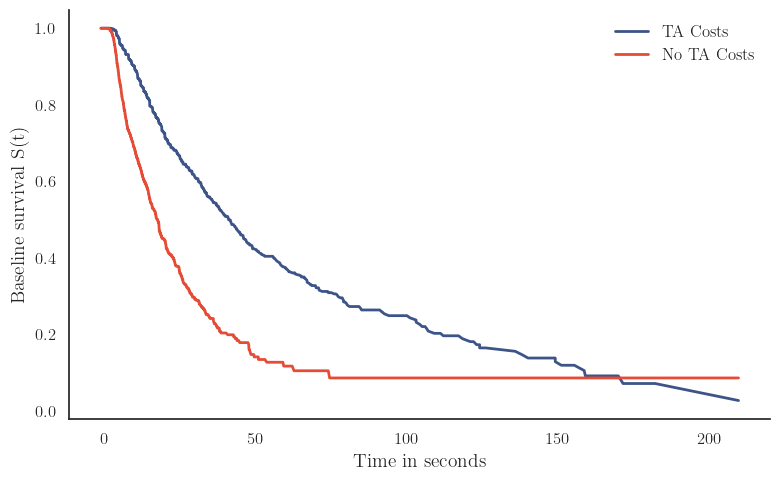

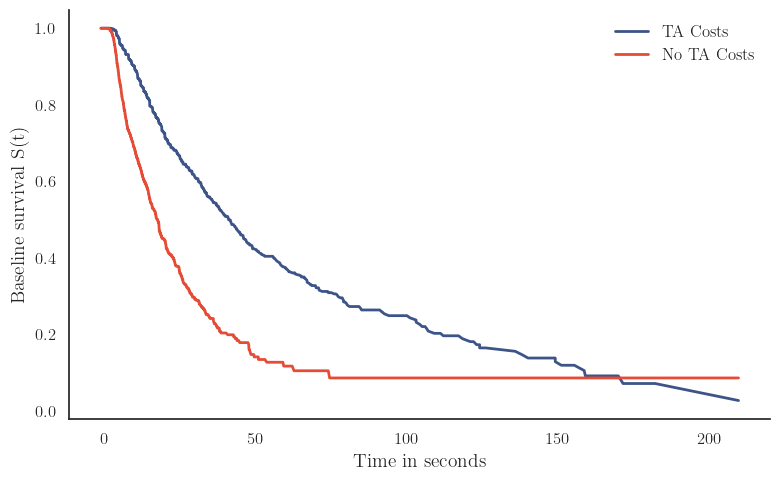

In [13]:
plot_cox_by_tacosts(plot_df, curve="survival")

## Agreement Curves

In [29]:
plot_df = df[
    (df['participant_role'] == 'Buyer') & 
    (df["gains_from_trade"] >= 0) &
    (df["TA_costs"] >= 0)
].copy()

In [32]:
def plot_agreement_prob_by_gft_ma3(df: pd.DataFrame, binning: str = "nearest"):
    """
    Plot P(agreement) vs gains_from_trade (0..60), using a centered 3-point moving average,
    with separate lines for each TA_costs value.
    """
    g = df.copy()

    # Convert gains_from_trade to integer bins
    if binning == "nearest":
        g["gft_int"] = g["gains_from_trade"].round().astype(int)
    elif binning == "floor":
        g["gft_int"] = np.floor(g["gains_from_trade"]).astype(int)
    elif binning == "ceil":
        g["gft_int"] = np.ceil(g["gains_from_trade"]).astype(int)
    else:
        raise ValueError("binning must be one of: 'nearest', 'floor', 'ceil'.")

    # Keep only 0..60
    g = g[(g["gft_int"] >= 0) & (g["gft_int"] <= 60)]

    set_plot_theme()
    fig, ax = plt.subplots()

    for ta, group in g.groupby("TA_costs"):
        summary = (
            group.groupby("gft_int")["agreement_dummy"]
            .agg(prob="mean", n="size")
            .reindex(range(0, 61))
        )
        summary["prob_ma3"] = summary["prob"].rolling(window=3, center=True, min_periods=1).mean()
        ax.plot(
            summary.index,
            summary["prob_ma3"],
            marker="o",
            label=f"TA_costs={ta}"
        )

    ax.set_xlim(0, 60)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel("Gains from trade")
    ax.set_ylabel("Probability of agreement (3-pt moving average)")
    ax.set_title("Probability of Agreement vs Gains from Trade (MA-3)")
    ax.legend(title="TA_costs")
    finalize_plot(ax)
    # Adjust legend labels
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    for label in labels:
        if label == "TA_costs=0.0":
            new_labels.append("No TA Costs")
        else:
            new_labels.append("TA Costs")
    ax.legend(handles, new_labels)

    return fig


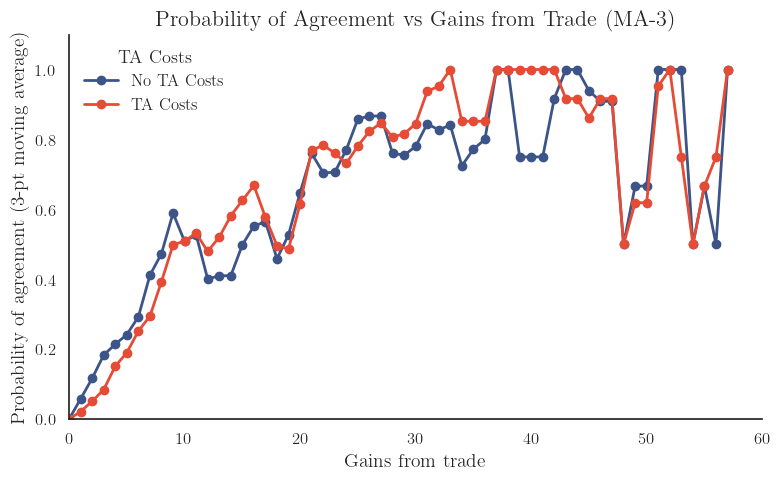

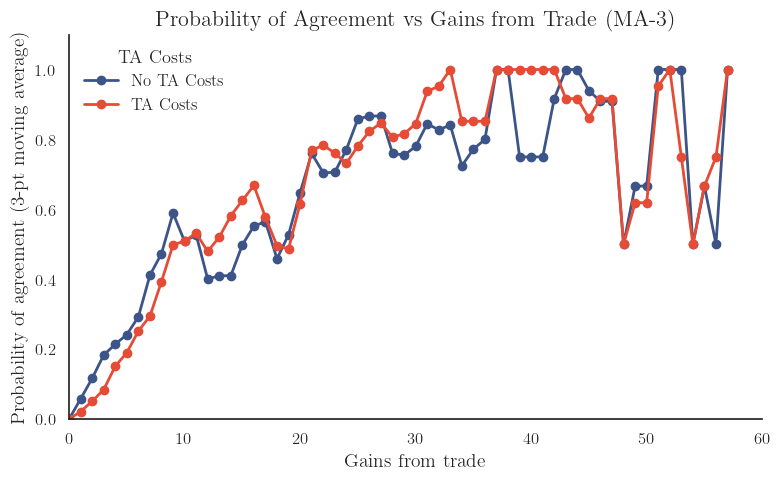

In [31]:
plot_agreement_prob_by_gft_ma3(plot_df, binning="nearest")

## Outcome Heatmap

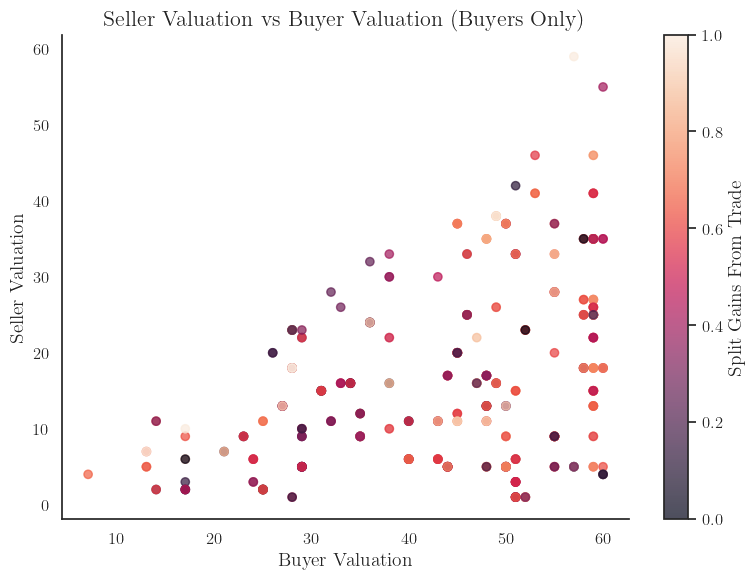

In [11]:
# Filter for buyers
plot_df = df[
    (df['participant_role'] == 'Buyer') & 
    (df["split_gains_from_trade"] >= 0) & 
    (df["split_gains_from_trade"] <= 1) & 
    (df["treatment"].isin(["T1", "T2"]))
].copy()

set_plot_theme()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    plot_df['buyer_valuation'],
    plot_df['seller_valuation'],
    c=plot_df['split_gains_from_trade'],
    alpha=0.7
)
plt.xlabel('Buyer Valuation')
plt.ylabel('Seller Valuation')
plt.title('Seller Valuation vs Buyer Valuation (Buyers Only)')
cbar = plt.colorbar(scatter)
cbar.set_label('Split Gains From Trade')
finalize_plot()
plt.show()

## Signaling

In [4]:
df_t34_buyer = df[(~np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])) & 
    (df['participant_role'] == 'Buyer') &
    (df["bargaining_outcome"]== "acceptance") &
    (df['treatment'].isin(['T3', 'T4']))]
df_t34_buyer = df_t34_buyer.dropna(subset=['valuation', 'last_offer_time'])
last_offer_time = smf.ols(formula='last_offer_time ~ valuation + C(participant_label)', 
    data=df_t34_buyer).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_t34_buyer['participant_label']},
    )

print(last_offer_time.summary())

                            OLS Regression Results                            
Dep. Variable:        last_offer_time   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     627.6
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           8.50e-33
Time:                        09:57:44   Log-Likelihood:                -2069.4
No. Observations:                 514   AIC:                             4259.
Df Residuals:                     454   BIC:                             4513.
Df Model:                          59                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

/Users/nicolasroever/opt/anaconda3/envs/bargaining_analysis/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [12]:
df_signal = df[(~np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])) & 
    (df['treatment'].isin(['T1', 'T2'])) & np.isclose(df['time_inconsistency_dummy'], 0)]
last_offer_time = smf.ols(formula='last_offer_time ~ C(participant_role) + C(participant_role):valuation + C(participant_role):I(valuation**2) +  gains_from_trade', 
    data=df_signal).fit()

print(last_offer_time.summary())

                            OLS Regression Results                            
Dep. Variable:        last_offer_time   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     4.897
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           5.62e-05
Time:                        10:01:43   Log-Likelihood:                -8293.6
No. Observations:                1877   AIC:                         1.660e+04
Df Residuals:                    1870   BIC:                         1.664e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

## Frictions information

In [11]:
print(df[['player_termination_dummy','ultimatum_indicator','participant_label']].isna().sum())

player_termination_dummy    0
ultimatum_indicator         8
participant_label           0
dtype: int64


In [13]:
df_with_TA = df[df["treatment"].isin(["T3", "T4"])].copy()

In [14]:
termination_risk = smf.ols(formula='player_termination_dummy ~ risk_elicitation_choice', 
    data=df_with_TA).fit()

print(termination_risk.summary())

                               OLS Regression Results                               
Dep. Variable:     player_termination_dummy   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.001
Method:                       Least Squares   F-statistic:                     4.265
Date:                      Mon, 14 Jul 2025   Prob (F-statistic):             0.0390
Time:                              13:45:26   Log-Likelihood:                -1734.2
No. Observations:                      3150   AIC:                             3472.
Df Residuals:                          3148   BIC:                             3485.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [12]:
termination_df = df[['player_termination_dummy', 'ultimatum_indicator', 'participant_label']].dropna()
termination = smf.ols(formula='player_termination_dummy ~ ultimatum_indicator', data=termination_df).fit(
    cov_type='cluster',
    cov_kwds={'groups': termination_df['participant_label']},
)

print(termination.summary())

                               OLS Regression Results                               
Dep. Variable:     player_termination_dummy   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                    0.7752
Date:                      Mon, 14 Jul 2025   Prob (F-statistic):              0.380
Time:                              13:43:52   Log-Likelihood:                -4149.1
No. Observations:                      6159   AIC:                             8302.
Df Residuals:                          6157   BIC:                             8316.
Df Model:                                 1                                         
Covariance Type:                    cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [ ]:
negotiation_data = df_gft30.drop_duplicates(subset='negotiation_id', keep='first')
efficiency = smf.ols(formula='agreement_dummy ~ C(information_asymmetry)', data=negotiation_data).fit(cov_type='cluster',
cov_kwds={
    'groups': negotiation_data['negotiation_id']
})

print(efficiency.summary())

In [4]:
df_gft30 = df[(df["gains_from_trade"] >= 0) & (df["gains_from_trade"] <= 30) ].copy()

In [7]:
avg_agreement_by_treatment = df_gft30.groupby('information_asymmetry')['agreement_dummy'].mean()
print(avg_agreement_by_treatment)

information_asymmetry
one-sided    0.523547
two-sided    0.469849
Name: agreement_dummy, dtype: float64


In [9]:
negotiation_data = df_gft30.drop_duplicates(subset='negotiation_id', keep='first')
efficiency = smf.ols(formula='agreement_dummy ~ C(information_asymmetry)', data=negotiation_data).fit(cov_type='cluster',
cov_kwds={
    'groups': negotiation_data['negotiation_id']
})

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:        agreement_dummy   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.701
Date:                Fri, 11 Jul 2025   Prob (F-statistic):             0.0545
Time:                        14:07:53   Log-Likelihood:                -1473.0
No. Observations:                2033   AIC:                             2950.
Df Residuals:                    2031   BIC:                             2961.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [ ]:




efficiency_df = negotiation_data.dropna(subset=['efficiency', 'TA_costs', 'information_asymmetry', 'positive_gains_symmetric_treatment', 'small_gains_from_trade_indicator'])
efficiency = smf.ols(formula='efficiency ~ C(TA_costs) + C(information_asymmetry) + positive_gains_symmetric_treatment + C(information_asymmetry):small_gains_from_trade_indicator', data=efficiency_df).fit(cov_type='cluster',
cov_kwds={
    'groups': efficiency_df['negotiation_id']
})

behavioral_efficiency_df = data.dropna(subset=['efficiency', 'TA_costs', 'information_asymmetry', 'positive_gains_symmetric_treatment', 'small_gains_from_trade_indicator', 'ultimatum_indicator', 'risk_elicitation_choice', 'time_preference_switching_points'])
behavioral_efficiency = smf.ols(formula='efficiency ~ C(TA_costs) + C(information_asymmetry) + positive_gains_symmetric_treatment + C(information_asymmetry):small_gains_from_trade_indicator + ultimatum_indicator  + risk_elicitation_choice + time_preference_switching_points', data=behavioral_efficiency_df).fit(cov_type='cluster',
cov_kwds={
    'groups': behavioral_efficiency_df['participant_code']
})




## Information Rents

In [4]:
df_t34 = df[(df['treatment'].isin(['T3', 'T4'])) & (df['bargaining_outcome'] == 'acceptance')].copy()
df_model_t34 = df_t34.dropna(subset=['payoff'])

model_t34 = smf.ols(formula='payoff ~ C(treatment):C(participant_role)', 
                      data=df_model_t34).fit(
    cov_type='cluster',
     cov_kwds={'groups': df_model_t34['participant_code']}
                      )
print(model_t34.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                    0.7686
Date:                Thu, 10 Jul 2025   Prob (F-statistic):              0.514
Time:                        11:45:20   Log-Likelihood:                -5529.2
No. Observations:                1722   AIC:                         1.107e+04
Df Residuals:                    1718   BIC:                         1.109e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

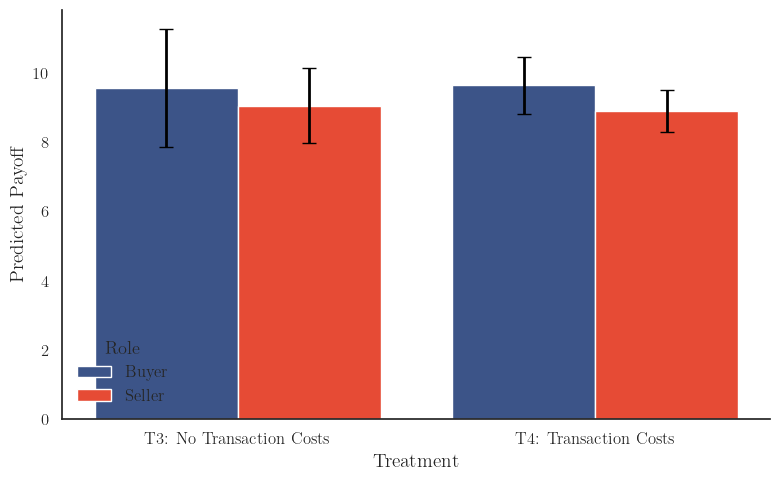

In [ ]:
# 1. Build grid of all (treatment × role) combos
roles = df_model_t34['participant_role'].unique()
treatments = ['T3', 'T4']
grid = pd.DataFrame(list(product(treatments, roles)),
                    columns=['treatment', 'participant_role'])

# 2. Get model’s predicted means & CIs
pred = model_t34.get_prediction(grid)
pred_df = pred.summary_frame(alpha=0.05)

grid = grid.assign(
    mean  = pred_df['mean'],
    lower = pred_df['mean_ci_lower'],
    upper = pred_df['mean_ci_upper']
)

# 3. Pivot so treatments are the index, roles the columns
plot_df = grid.pivot(index='treatment',
                     columns='participant_role',
                     values=['mean', 'lower', 'upper'])

# 4. Extract arrays
means = plot_df['mean']      # DataFrame: index=treatments, cols=roles
lower = plot_df['lower']
upper = plot_df['upper']

n_treat = len(treatments)
n_roles = len(roles)
x = np.arange(n_treat)
width = 0.8 / n_roles  # total bar‐group width of 0.8

set_plot_theme()
# 5. Plot
fig, ax = plt.subplots()

for i, role in enumerate(roles):
    y = means[role].values
    err_low  = y - lower[role].values
    err_high = upper[role].values - y
    yerr = np.vstack([err_low, err_high])
    
    # center the group around each x[i]
    offset = (i - (n_roles-1)/2) * width
    ax.bar(x + offset, y, width,
           yerr=yerr, capsize=5,
           label=role)

# 6. Tweak axes/legend
ax.set_xticks(x)
ax.set_xticklabels(['T3: No Transaction Costs', 'T4: Transaction Costs'])
ax.set_ylabel('Average Payoff')
ax.legend(title='Role')
finalize_plot(ax)
plt.show()


In [ ]:
df_t12 = df[(df['treatment'].isin(['T1', 'T2'])) & (df['bargaining_outcome'] == 'acceptance')].copy()
df_model_t12 = df_t12.dropna(subset=['split_gains_from_trade'])

model_t12 = smf.ols(formula='split_gains_from_trade ~ C(participant_role) + C(participant_role):valuation', 
                      data=df_model_t12).fit(
    cov_type='cluster',
     cov_kwds={'groups': df_model_t12['participant_code']}
                      )
print(model_t12.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.022
Model:                                OLS   Adj. R-squared:                  0.016
Method:                     Least Squares   F-statistic:                     4.230
Date:                    Wed, 09 Jul 2025   Prob (F-statistic):            0.00868
Time:                            13:31:43   Log-Likelihood:                -190.33
No. Observations:                     456   AIC:                             388.7
Df Residuals:                         452   BIC:                             405.1
Df Model:                               3                                         
Covariance Type:                  cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [6]:
avg_split_gains_seller_t1_t2 = df.loc[
    (df['participant_role'] == 'Seller') &
    (df['treatment'].isin([ 'T2']))
]['split_gains_from_trade'].median()
print(f"Average split_gains_from_trade for Sellers (T1 or T2): {avg_split_gains_seller_t1_t2:.4f}")

avg_split_gains_seller_t3_t4 = df.loc[
    (df['participant_role'] == 'Seller') &
    (df['treatment'].isin(['T4']))
]['split_gains_from_trade'].median()
print(f"Average split_gains_from_trade for Sellers (T3 or T4): {avg_split_gains_seller_t3_t4:.4f}")

Average split_gains_from_trade for Sellers (T1 or T2): 0.4479
Average split_gains_from_trade for Sellers (T3 or T4): 0.5000


In [18]:
df_model = df[(df["participant_role"] == "Seller") & (df["treatment"].isin([ 'T1', 'T3']))].copy()
df_model = df_model.dropna(subset=['split_gains_from_trade'])


information_rent = smf.ols(formula='payoff ~ seller_info_public + gains_from_trade',  
                      data=df_model).fit()
print(information_rent.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     42.99
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           2.47e-17
Time:                        13:34:14   Log-Likelihood:                -1092.8
No. Observations:                 336   AIC:                             2192.
Df Residuals:                     333   BIC:                             2203.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.6693      1

In [6]:
def plot_last_offer_time_vs_valuation_t34(df: pd.DataFrame):

    df_signal = df[(~np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])) & 
    (df['participant_role'] == 'Buyer') &
    (df["bargaining_outcome"]== "acceptance") &
    (df['treatment'].isin(['T3', 'T4']))]


    set_plot_theme()
    fig, ax = plt.subplots(figsize=(8, 6))

    # 1) scatter
    sns.scatterplot(
        x='valuation',
        y='last_offer_time',
        data=df_signal,
        hue='treatment',
        alpha=0.7
    )

    # 2) linear regression line (through all points)
    sns.regplot(
        x='valuation',
        y='last_offer_time',
        data=df_signal,
        scatter=False,
        label='Linear fit'
    )

    plt.xlabel('Valuation (Equals Gains from Trade)')
    plt.ylabel('Time of Accepted Offer (Seconds)')
    plt.legend(title='Treatment')
    finalize_plot(ax)
    
    return fig

In [5]:
df_signal = df[(~np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])) & 
    (df['participant_role'] == 'Buyer') &
    (df["bargaining_outcome"]== "acceptance") &
    (df['treatment'].isin(['T3', 'T4']))]

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_29776/3753914493.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_last_offer_time_vs_valuation_t34(df).show()


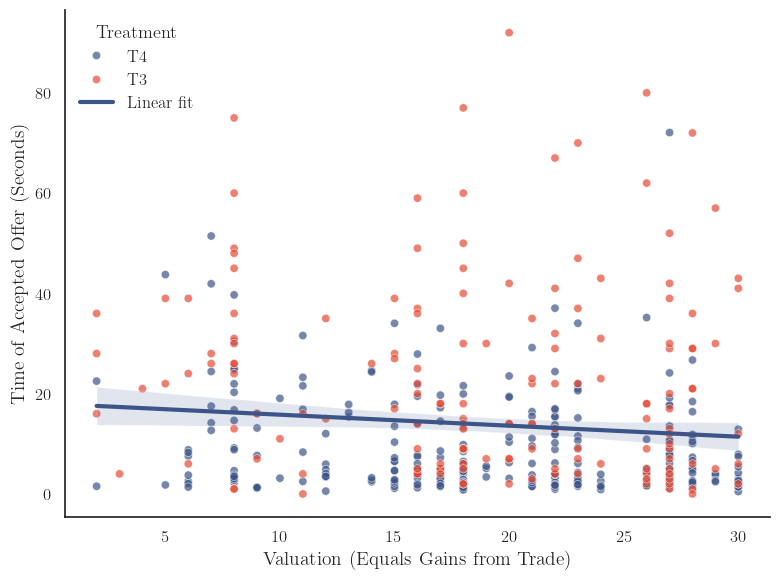

In [7]:
plot_last_offer_time_vs_valuation_t34(df).show()

In [ ]:
# 1. Filter for Sellers
df_seller = df[df['participant_role'] == 'Seller'].copy()

# 2. Create pooled treatment groups
df_seller['pooled_treatment'] = df_seller['treatment'].map({
    'T1': 'T1 and T2', 'T2': 'T1 and T2',
    'T3': 'T3 and T4', 'T4': 'T3 and T4'
})

# 3. Draw 2 boxplots (one per pooled treatment group)
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='pooled_treatment',
    y='split_gains_from_trade',
    data=df_seller,
    order=['T1 and T2', 'T3 and T4'],
    palette='Set2'
)
plt.xlabel('Pooled Treatment', fontsize=12)
plt.ylabel('Split Gains From Trade', fontsize=12)
plt.title('Seller: Split Gains From Trade by Pooled Treatment', fontsize=14)
plt.ylim(-0.5, 1.5)

# 4. t-test between pooled treatment groups
g1 = df_seller.loc[df_seller['pooled_treatment'] == 'T1 and T2', 'split_gains_from_trade']
g2 = df_seller.loc[df_seller['pooled_treatment'] == 'T3 and T4', 'split_gains_from_trade']
tstat, pval = ttest_ind(g1, g2, equal_var=False, nan_policy='omit')

# Add p-value to the plot
plt.text(0.5, 1.4, f'p-value of mean difference: {pval:.3f}', ha='center', fontsize=12, color='black')

plt.tight_layout()
plt.show()

# 5. Print t-test result
print(f'Comparison: T1 and T2 vs T3 and T4\n t-statistic: {tstat}\n p-value: {pval}')

## Signaling Regressions

In [ ]:
df_signal = df[(~np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])) & 
    (df['participant_role'] == 'Buyer') &
    (df["bargaining_outcome"]== "acceptance") &
    (df['treatment'].isin(['T3', 'T4']))]

In [ ]:
t34 = df[df['treatment'].isin(['T3', 'T4'])].copy()
t34_buyer = t34[t34['participant_role'] == 'Buyer']

In [8]:
df_signal = df[(~np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])) & 
    (df['participant_role'] == 'Buyer') &
    (df["bargaining_outcome"]== "acceptance") &
    (df['treatment'].isin(['T3', 'T4']))]

model = smf.ols('last_offer_time ~ valuation', data=df_signal).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        last_offer_time   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     4.669
Date:                Tue, 08 Jul 2025   Prob (F-statistic):             0.0312
Time:                        14:31:01   Log-Likelihood:                -1822.1
No. Observations:                 440   AIC:                             3648.
Df Residuals:                     438   BIC:                             3656.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.9944      2.062      8.727      0.0

## Who gets split of gains from trade

In [53]:
model_t12 = smf.ols(formula='split_gains_from_trade ~ relative_valuation', 
                      data=df[df['treatment'].isin(["T1", "T2"])]).fit()
print(model_t12.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.001
Model:                                OLS   Adj. R-squared:                 -0.001
Method:                     Least Squares   F-statistic:                    0.5239
Date:                    Thu, 03 Jul 2025   Prob (F-statistic):              0.470
Time:                            13:37:16   Log-Likelihood:                -195.15
No. Observations:                     456   AIC:                             394.3
Df Residuals:                         454   BIC:                             402.6
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Signaling Prediction

In [23]:
print(len(df))
df_signal = df[np.isclose(df["id_in_group"], df['accepted_by_id_in_group'])]
print(len(df_signal))

3448
688


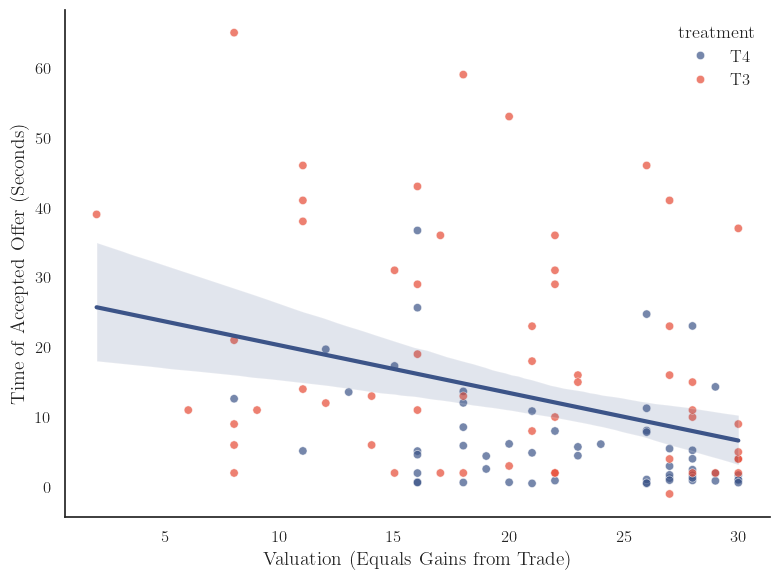

In [30]:
buyers_t3_t4_signal = df_signal[
    (df_signal['participant_role'] == 'Buyer') &
    (df_signal['treatment'].isin(['T3', 'T4']))
].copy()

set_plot_theme()
fig, ax = plt.subplots(figsize=(8, 6))

# 1) scatter
sns.scatterplot(
    x='valuation',
    y='last_offer_time',
    data=buyers_t3_t4_signal,
    hue='treatment',
    alpha=0.7
)

# 2) linear regression line (through all points)
sns.regplot(
    x='valuation',
    y='last_offer_time',
    data=buyers_t3_t4_signal,
    scatter=False,
    label='Linear fit'
)

plt.xlabel('Valuation (Equals Gains from Trade)')
plt.ylabel('Time of Accepted Offer (Seconds)')
finalize_plot(ax)
plt.show()

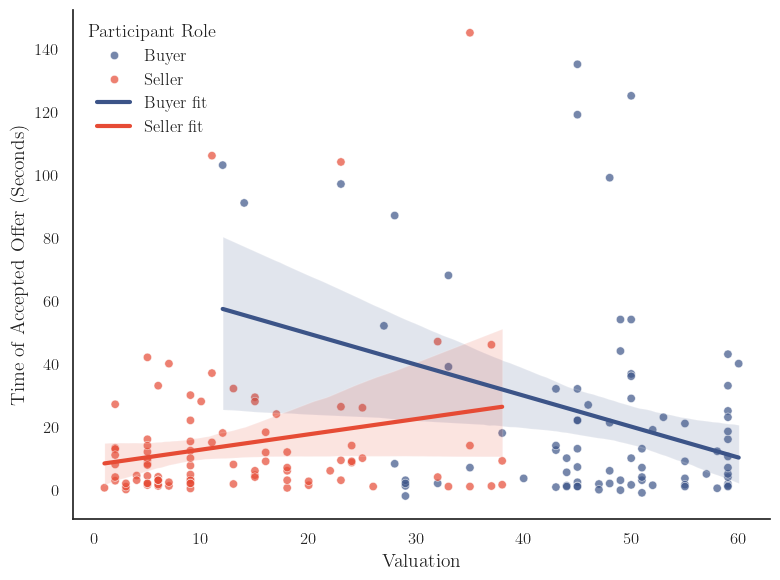

In [34]:
# filter T1 & T2
df = df_signal[df_signal['treatment'].isin(['T1', 'T2'])]

set_plot_theme()

plt.figure(figsize=(8, 6))

# scatter by role
sns.scatterplot(
    x='valuation',
    y='last_offer_time',
    data=df,
    hue='participant_role',
    alpha=0.7
)

# linear fit for Buyers
sns.regplot(
    x='valuation',
    y='last_offer_time',
    data=df[df['participant_role'] == 'Buyer'],
    scatter=False,
    label='Buyer fit',
)

# linear fit for Sellers
sns.regplot(
    x='valuation',
    y='last_offer_time',
    data=df[df['participant_role'] == 'Seller'],
    scatter=False,
    label='Seller fit',
)

plt.xlabel('Valuation')
plt.ylabel('Time of Accepted Offer (Seconds)')
plt.legend(title='Participant Role')
finalize_plot()
plt.show()

## Efficeincy

In [25]:

# 2) Prepare output dict
rates = {}
df_filtered = df[df['gains_from_trade'] > 0].copy()
# 3) Loop through treatments
for t in ['T1', 'T2', 'T3', 'T4']:
    sub = df_filtered[df_filtered['treatment'] == t]
    rate = (sub['bargaining_outcome'] == 'acceptance').mean()
    rates[f'acceptance_{t}'] = int(round(rate * 100))

In [26]:
rates

{'acceptance_T1': 56,
 'acceptance_T2': 59,
 'acceptance_T3': 54,
 'acceptance_T4': 53}

In [15]:
df["bargaining_outcome"].value_counts()

bargaining_outcome
acceptance            1352
Player                1194
Random_Termination     902
Name: count, dtype: int64

<>:25: SyntaxWarning: invalid escape sequence '\g'
<>:25: SyntaxWarning: invalid escape sequence '\g'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_65122/2876205939.py:25: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('Fraction of Acceptance where  \n Gains from Trade $\geq$ 0')
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_65122/2876205939.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p.index, rotation=45, ha='right')


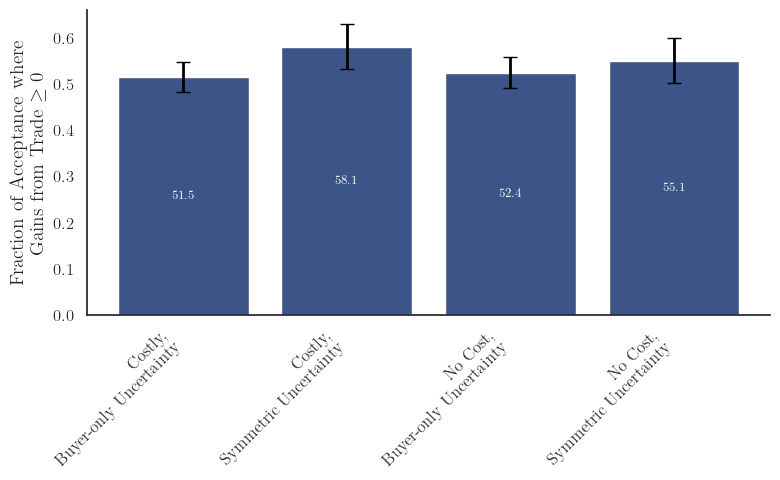

In [ ]:
def plot_acceptance_rates(df: pd.DataFrame):
    """
    Plot acceptance rates for each treatment condition, showing the fraction of
    acceptance where gains from trade are non-negative.
    """

 # --- 1. Filter --------------------------------------------------------------
    df_filtered = df[df['gains_from_trade'] >= 0].copy()

    # --- 2. Human-readable treatment labels -------------------------------------
    labels_map = {
        'T1': 'No Cost,\nSymmetric Uncertainty',
        'T2': 'Costly,\nSymmetric Uncertainty',
        'T3': 'No Cost,\nBuyer-only Uncertainty',
        'T4': 'Costly,\nBuyer-only Uncertainty'
    }
    df_filtered['treatment_label'] = df_filtered['treatment'].map(labels_map)

    # --- 3. Acceptance rates and 95 % CIs ---------------------------------------
    grouped = df_filtered.groupby('treatment_label')['bargaining_outcome']
    p   = grouped.apply(lambda x: (x == 'acceptance').mean())   # proportion
    n   = grouped.count()
    se  = np.sqrt(p * (1 - p) / n)      # standard error
    ci95 = 1.96 * se                    # 95 % half-width (Wald)

    # --- 4. Plot ----------------------------------------------------------------
    set_plot_theme()
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(p.index, p, yerr=ci95, capsize=5)

    ax.set_ylabel('Fraction of Acceptance where  \n Gains from Trade $\geq$ 0')
    ax.set_xticklabels(p.index, rotation=45, ha='right')

    # --- Write the percentage inside each bar -----------------------------------
    for rect, frac in zip(bars, p):
        bar_mid_y = rect.get_height() / 2
        ax.text(
            rect.get_x() + rect.get_width() / 2,  # bar centre (x)
            bar_mid_y,                            # halfway up the bar (y)
            f'{frac*100:.1f} %',                  # e.g. “74.3 %”
            ha='center', va='center',
            color='white', fontweight='bold', fontsize=9
        )

    finalize_plot(ax)
    return fig

## Emergence of Bargaining Equilibrium

In [50]:
data_t12 = df[df['treatment'].isin(['T1', 'T2']) & pd.notna(df['number_of_offers'])]

model_t12 = smf.ols(formula='bargaining_time_full_sec ~ C(participant_role):valuation + C(participant_code)', 
                      data=data_t12).fit()

print(model_t12.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.246
Model:                                  OLS   Adj. R-squared:                  0.216
Method:                       Least Squares   F-statistic:                     8.312
Date:                      Tue, 01 Jul 2025   Prob (F-statistic):           6.84e-64
Time:                              09:41:26   Log-Likelihood:                -7717.0
No. Observations:                      1724   AIC:                         1.557e+04
Df Residuals:                          1658   BIC:                         1.593e+04
Df Model:                                65                                         
Covariance Type:                  nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [ ]:
pystout(models=[first_offer, split_gains, efficiency, agreement],
    file='sandbox.tex',
    addnotes=['\\textit{Notes:} These regressions are run on the data from the treatments with asymmetric uncertainty. Dummy First Offer is indicator equal to 1 if the player has made the first offer, split gains from trade is percentage of the surplus the player extracts from a successfull trade (we exclude transaction costs for this measure), efficiency is indicator equal to 1 if an agreement was reached and 0 otherwise (surplus is always at leas zero in the considered treatmends) and Dummy Agreement is an indicator equal to 1 if an agreement was reached.'],
    digits=2,
    endog_names=['Number of Offers (T1 and T2)', "Split Gains from Trade", "Efficiency", "Dummy Agreement"],
    varlabels={'const':'Constant','first_offer':'First Offer', 'split_gains_from_trade':'Split Gains from Trade', 'efficiency':'Efficiency', 'agreement_dummy':'Dummy Agreement', 'C(participant_role)[T.Seller]':'Seller', 'C(TA_costs)[T.0.05]':'TA Costs $= 0.05$', 'gains_from_trade':'Gains from Trade'},
    modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
    )

In [48]:
def plot_gains_from_trade_number_offers(df, treatments):
    """
    Scatterplot of Gains from Trade vs. Number of Offers colored by treatment,
    with a single pooled regression line across all selected treatments.
    """
    # Filter for specified treatments
    df_plot = df[df['treatment'].isin(treatments)]

    set_plot_theme()
    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter plot, colored by treatment
    sns.scatterplot(
        x='gains_from_trade',
        y='number_of_offers',
        data=df_plot,
        alpha=0.7,
        ax=ax
    )

    # Pooled regression line across all treatments
    sns.regplot(
        x='gains_from_trade',
        y='number_of_offers',
        data=df_plot,
        scatter=False,
        ax=ax,
        line_kws={
            'color': color_scheme[0],
            'label': 'Pooled fit'
        }
    )

    # Axis labels and legend
    ax.set_xlabel('Gains from Trade (in Euros)')
    ax.set_ylabel('Number of Offers')
    plt.tight_layout()

    finalize_plot(ax)

    return fig

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_83587/3371735104.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_gains_from_trade_number_offers(df, ['T1', 'T2']).show()


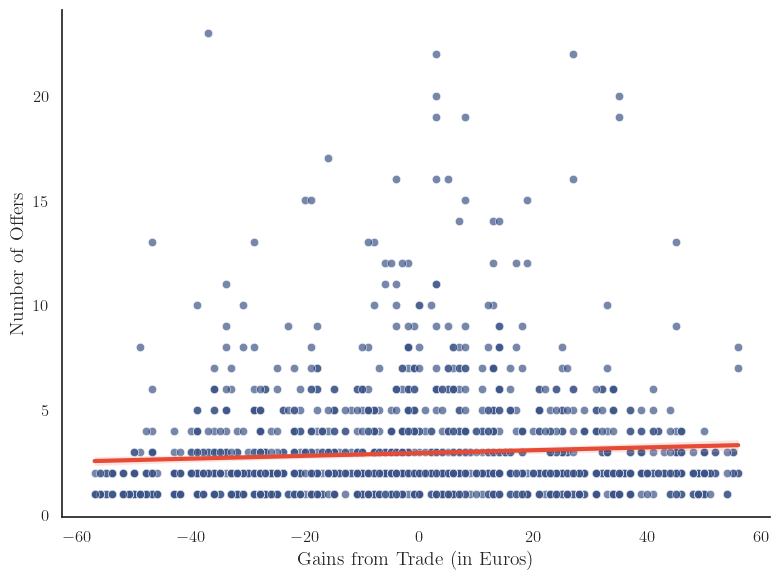

In [47]:
plot_gains_from_trade_number_offers(df, ['T1', 'T2']).show()

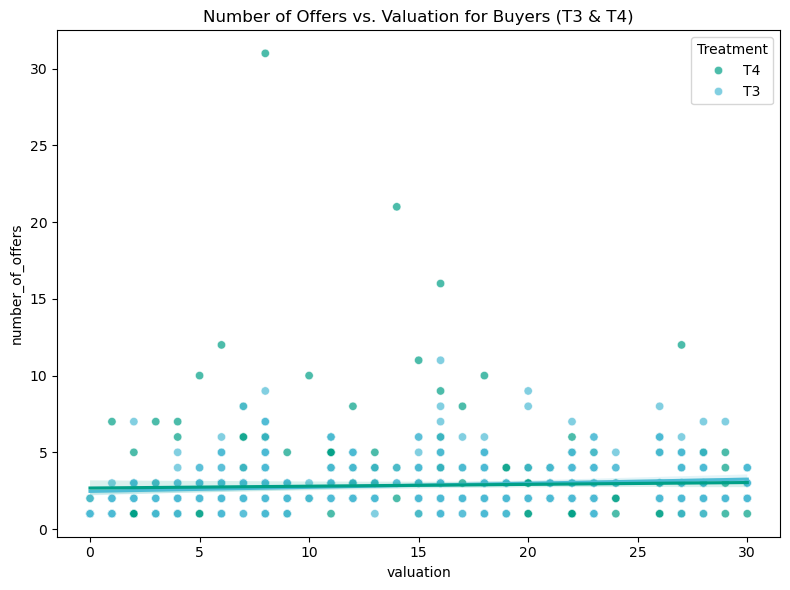

In [19]:
buyers_t3_t4 = df[(df['participant_role'] == 'Buyer') & (df['treatment'].isin(['T3', 'T4']))]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='valuation',
    y='number_of_offers',
    data=buyers_t3_t4,
    hue='treatment',
    palette={'T3': color_scheme[2], 'T4': color_scheme[3]},
    alpha=0.7
)
plt.xlabel('Valuation')
plt.ylabel('Number of Offers')
plt.title('Number of Offers vs. Valuation for Buyers (T3 & T4)')
plt.legend(title='Treatment')
plt.tight_layout()
sns.regplot(
    x='valuation',
    y='number_of_offers',
    data=buyers_t3_t4[buyers_t3_t4['treatment']=='T3'],
    scatter=False,
    label='T3 fit',
    line_kws={'color': color_scheme[2]}
)
sns.regplot(
    x='valuation',
    y='number_of_offers',
    data=buyers_t3_t4[buyers_t3_t4['treatment']=='T4'],
    scatter=False,
    label='T4 fit',
    line_kws={'color': color_scheme[3]}
)
plt.show()

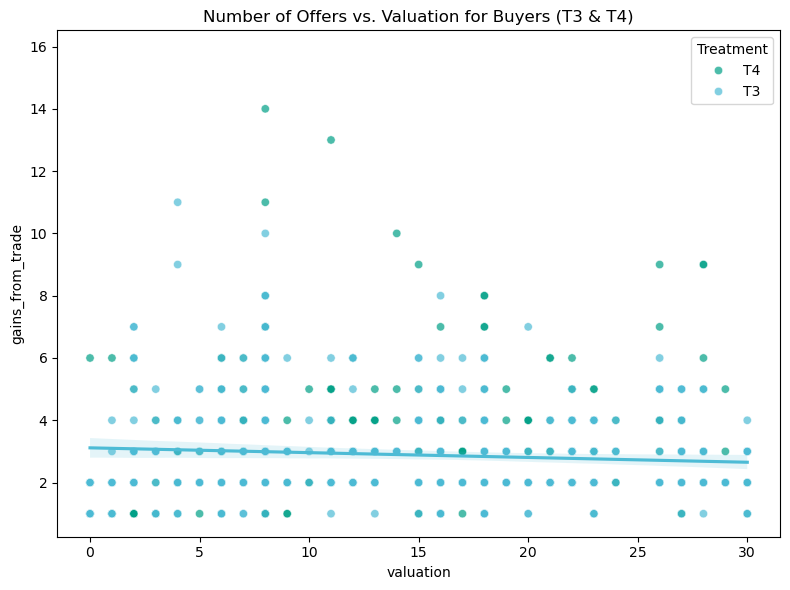

In [28]:
buyers_t3_t4 = df[(df['participant_role'] == 'Seller') & (df['treatment'].isin(['T3', 'T4']))]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='gains_from_trade',
    y='number_of_offers',
    data=buyers_t3_t4,
    hue='treatment',
    palette={'T3': color_scheme[2], 'T4': color_scheme[3]},
    alpha=0.7
)
plt.xlabel('Valuation')
plt.ylabel('Number of Offers')
plt.title('Number of Offers vs. Valuation for Buyers (T3 & T4)')
plt.legend(title='Treatment')
plt.tight_layout()
sns.regplot(
    x='gains_from_trade',
    y='number_of_offers',
    data=buyers_t3_t4[buyers_t3_t4['treatment']=='T3'],
    scatter=False,
    label='T3 fit',
    line_kws={'color': color_scheme[2]}
)
sns.regplot(
    x='valuation',
    y='gains_from_trade',
    data=buyers_t3_t4[buyers_t3_t4['treatment']=='T4'],
    scatter=False,
    label='T4 fit',
    line_kws={'color': color_scheme[3]}
)
plt.show()

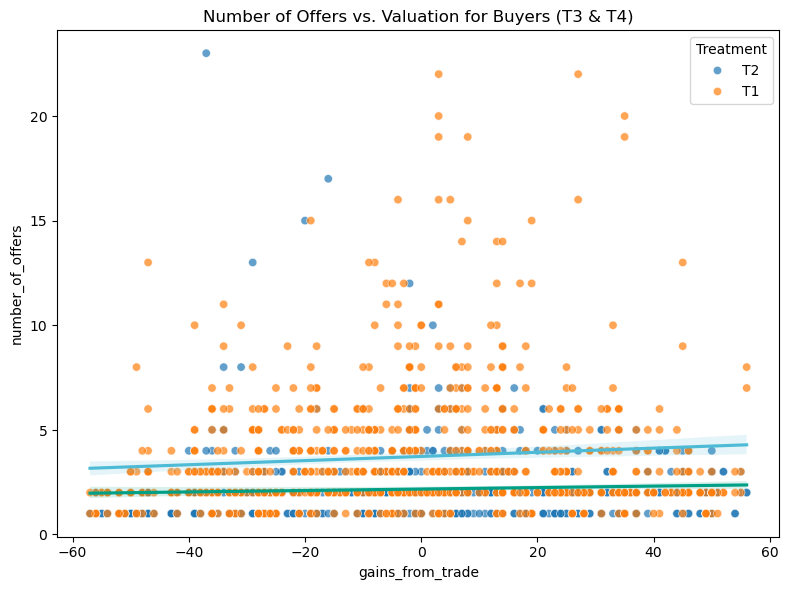

In [32]:
buyers_t3_t4 = df[(df['treatment'].isin(['T1', 'T2']))]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='gains_from_trade',
    y='number_of_offers',
    data=buyers_t3_t4,
    hue='treatment',
    alpha=0.7
)
plt.xlabel('Valuation')
plt.ylabel('Number of Offers')
plt.title('Number of Offers vs. Valuation for Buyers (T3 & T4)')
plt.legend(title='Treatment')
plt.tight_layout()
sns.regplot(
    x='gains_from_trade',
    y='number_of_offers',
    data=buyers_t3_t4[buyers_t3_t4['treatment']=='T1'],
    scatter=False,
    label='T1 fit',
    line_kws={'color': color_scheme[2]}
)
sns.regplot(
    x='gains_from_trade',
    y='number_of_offers',
    data=buyers_t3_t4[buyers_t3_t4['treatment']=='T2'],
    scatter=False,
    label='T2 fit',
    line_kws={'color': color_scheme[3]}
)
plt.show()

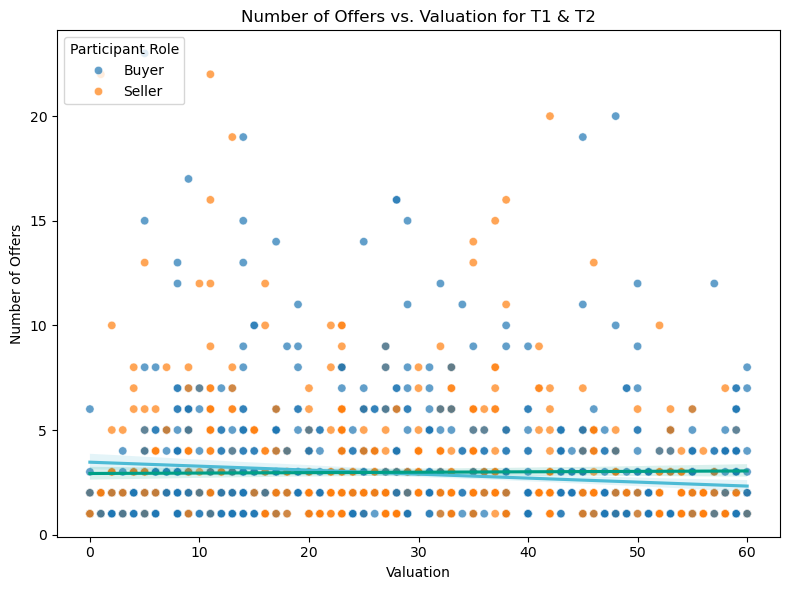

In [27]:
# Subset sellers in T1 & T2
df_t1_t2 = df[
    (df['treatment'].isin(['T1', 'T2']))
]

plt.figure(figsize=(8, 6))

# Base scatter
sns.scatterplot(
    x='valuation',
    y='number_of_offers',
    data=df_t1_t2,
    hue='participant_role',
    alpha=0.7
)

# T1 regression line
sns.regplot(
    x='valuation',
    y='number_of_offers',
    data=df_t1_t2[df_t1_t2['participant_role']=='Seller'],
    scatter=False,
    line_kws={'color': color_scheme[2], 'label': 'Seller Fit'}
)

# T2 regression line
sns.regplot(
    x='valuation',
    y='number_of_offers',
    data=df_t1_t2[df_t1_t2['participant_role']=='Buyer'],
    scatter=False,
    line_kws={'color': color_scheme[3], 'label': 'Buyer fit'}
)

plt.xlabel('Valuation')
plt.ylabel('Number of Offers')
plt.title('Number of Offers vs. Valuation for T1 & T2')
plt.legend(title='Participant Role', loc='upper left')
plt.tight_layout()
plt.show()

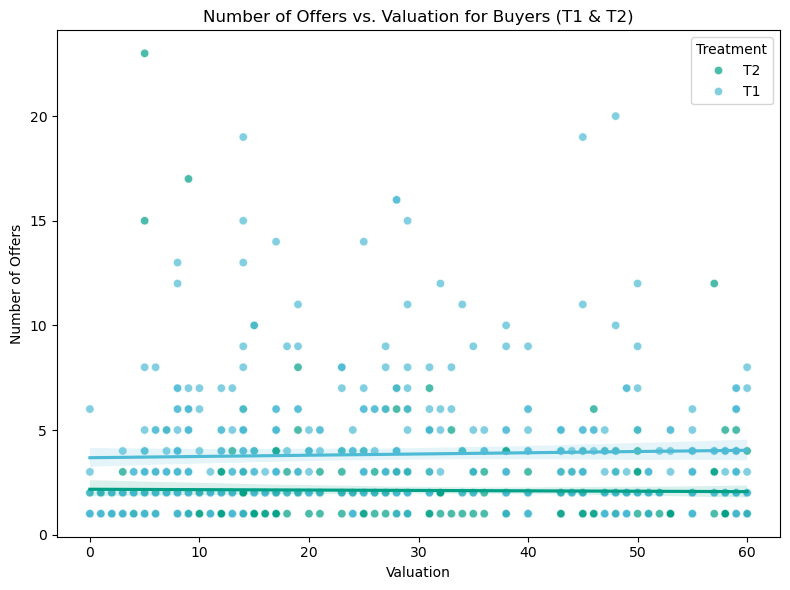

In [21]:
# Subset buyers in T1 & T2
buyers_t1_t2 = df[
    (df['participant_role'] == 'Buyer') &
    (df['treatment'].isin(['T1', 'T2']))
]

plt.figure(figsize=(8, 6))

# Base scatter
sns.scatterplot(
    x='valuation',
    y='number_of_offers',
    data=buyers_t1_t2,
    hue='treatment',
    palette={'T1': color_scheme[2], 'T2': color_scheme[3]},
    alpha=0.7
)

# T1 regression line
sns.regplot(
    x='valuation',
    y='number_of_offers',
    data=buyers_t1_t2[buyers_t1_t2['treatment']=='T1'],
    scatter=False,
    line_kws={'color': color_scheme[2], 'label': 'T1 fit'}
)

# T2 regression line
sns.regplot(
    x='valuation',
    y='number_of_offers',
    data=buyers_t1_t2[buyers_t1_t2['treatment']=='T2'],
    scatter=False,
    line_kws={'color': color_scheme[3], 'label': 'T2 fit'}
)

plt.xlabel('Valuation')
plt.ylabel('Number of Offers')
plt.title('Number of Offers vs. Valuation for Buyers (T1 & T2)')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()

In [25]:
sellers_t34 = smf.ols(formula='number_of_offers ~ C(participant_role):valuation + C(participant_code)', 
                      data=df).fit()

print(sellers_t34.summary())

                            OLS Regression Results                            
Dep. Variable:       number_of_offers   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     8.207
Date:                Tue, 01 Jul 2025   Prob (F-statistic):          1.51e-122
Time:                        09:04:59   Log-Likelihood:                -7175.0
No. Observations:                3448   AIC:                         1.461e+04
Df Residuals:                    3318   BIC:                         1.541e+04
Df Model:                         129                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Efficiency over Time

In [15]:
efficiency = smf.ols(formula='efficiency ~ round', 
                      data=df).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.281
Date:                Tue, 01 Jul 2025   Prob (F-statistic):              0.258
Time:                        08:21:48   Log-Likelihood:                -2276.1
No. Observations:                3448   AIC:                             4556.
Df Residuals:                    3446   BIC:                             4569.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6546      0.020     33.012      0.0

## Group Fixed Effects

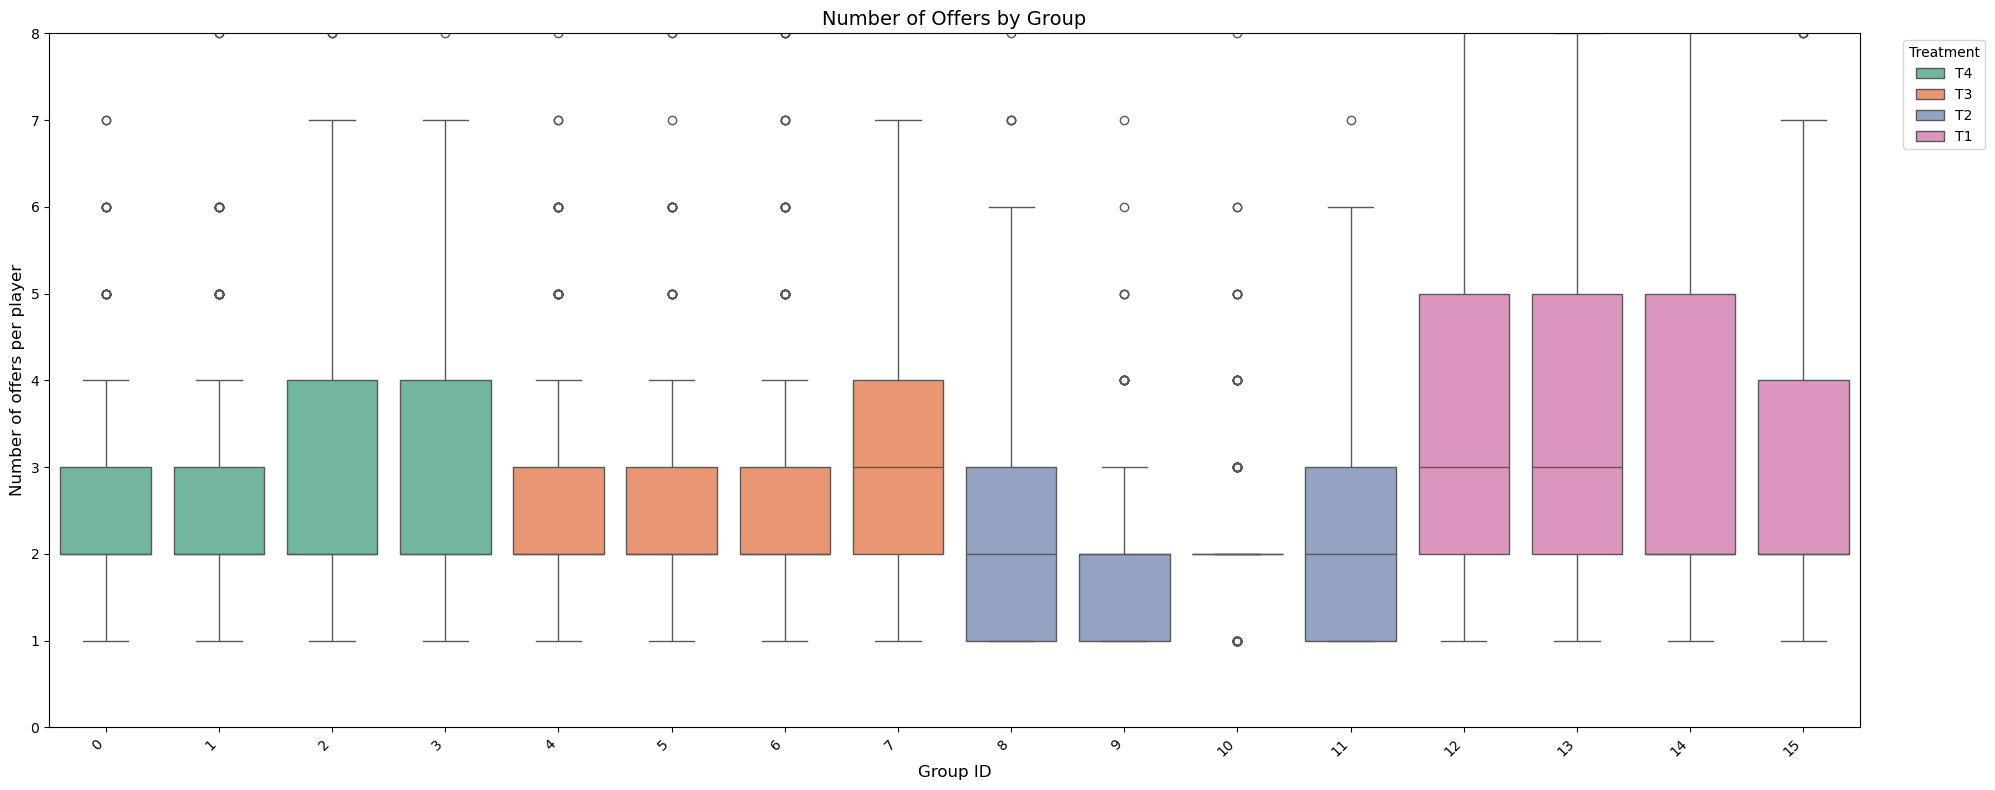

In [14]:
plt.figure(figsize=(20, 8))
sns.boxplot(
    x='group_id',
    y='number_of_offers',
    hue='treatment',
    data=df,
    order=sorted(df['group_id'].unique()),
    palette='Set2'  # or pick any other seaborn/matplotlib palette
)
plt.xlabel('Group ID', fontsize=12)
plt.ylabel('Number of offers per player', fontsize=12)
plt.title('Number of Offers by Group', fontsize=14)
plt.ylim(0, 8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Treatment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
error = df[df['bargaining_time_full_sec'] > 120]

## Bargaining Power

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_98577/2419302285.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


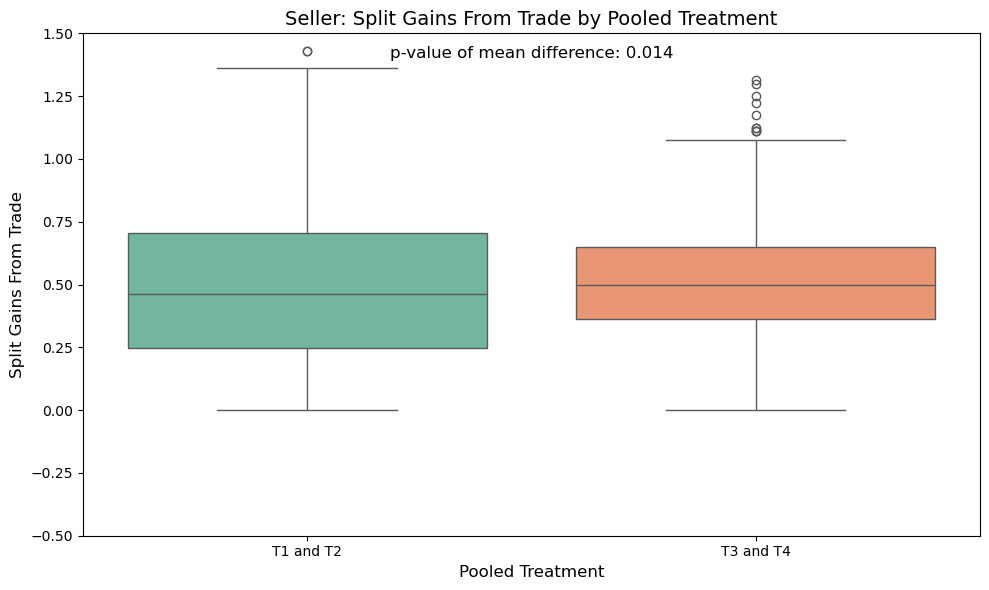

Comparison: T1 and T2 vs T3 and T4
 t-statistic: -2.456124038104738
 p-value: 0.014337328194361072


In [6]:
df_positive_gains = df[df["gains_from_trade"] > 0]

bargaining_power = smf.ols(formula='majority_gains_from_trade_indicator ~ C(participant_role):C(information_asymmetry) + valuation:C(participant_role)', 
                      data=df_positive_gains).fit()

print(bargaining_power.summary())

                                     OLS Regression Results                                    
Dep. Variable:     majority_gains_from_trade_indicator   R-squared:                       0.027
Model:                                             OLS   Adj. R-squared:                  0.023
Method:                                  Least Squares   F-statistic:                     7.350
Date:                                 Fri, 27 Jun 2025   Prob (F-statistic):           8.28e-07
Time:                                         14:08:16   Log-Likelihood:                -954.79
No. Observations:                                 1348   AIC:                             1922.
Df Residuals:                                     1342   BIC:                             1953.
Df Model:                                            5                                         
Covariance Type:                             nonrobust                                         
                                        

## Emergencce of equilibtium

In [85]:
df_4 = df.loc[
        df['treatment'].isin(['T1', 'T2']) &
        (df['participant_role'] == 'Buyer') & 
        (df['split_gains_from_trade'] <=  -700)
    ]



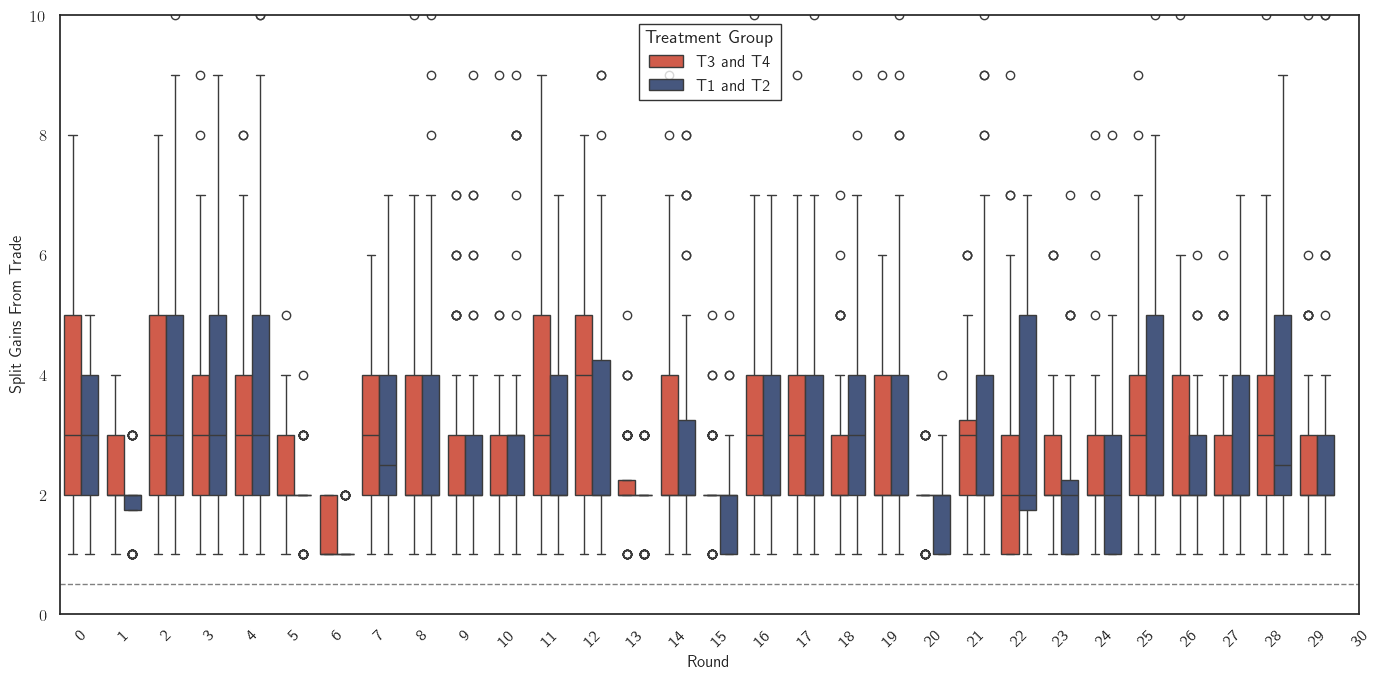

In [91]:
# 1. Filter buyers in T1–T4
df_plot = df.copy()

# 2. Make T1+T2 vs T3+T4 groups
df_plot['group'] = df_plot['treatment'].map({
    'T1':'T1 and T2', 'T2':'T1 and T2',
    'T3':'T3 and T4', 'T4':'T3 and T4'
})

# 3. Shift your round numbers so the min becomes 1
min_round = df_plot['round'].min()          # e.g. 4
df_plot['round_num'] = df_plot['round'] - min_round + 1
n_rounds = df_plot['round_num'].max()       # should be 30 if rounds ran 4–33

# 4. Draw the side-by-side boxplots
plt.figure(figsize=(14,7))
ax = sns.boxplot(
    x='round_num',
    y='number_of_offers',
    hue='group',
    data=df_plot,
    order=range(1, n_rounds+1),
    palette={'T1 and T2':'C0','T3 and T4':'C1'},
    dodge=True
)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=1)

# 5. Force the x-ticks to 1…n_rounds
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Split Gains From Trade', fontsize=12)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, n_rounds+1))
ax.set_xticklabels(range(0, n_rounds+1), rotation=45)
leg = ax.legend(
    title='Treatment Group',
    frameon=True,     # turn on the frame
    fancybox=False    # straight corners
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1)
plt.tight_layout()
plt.show()

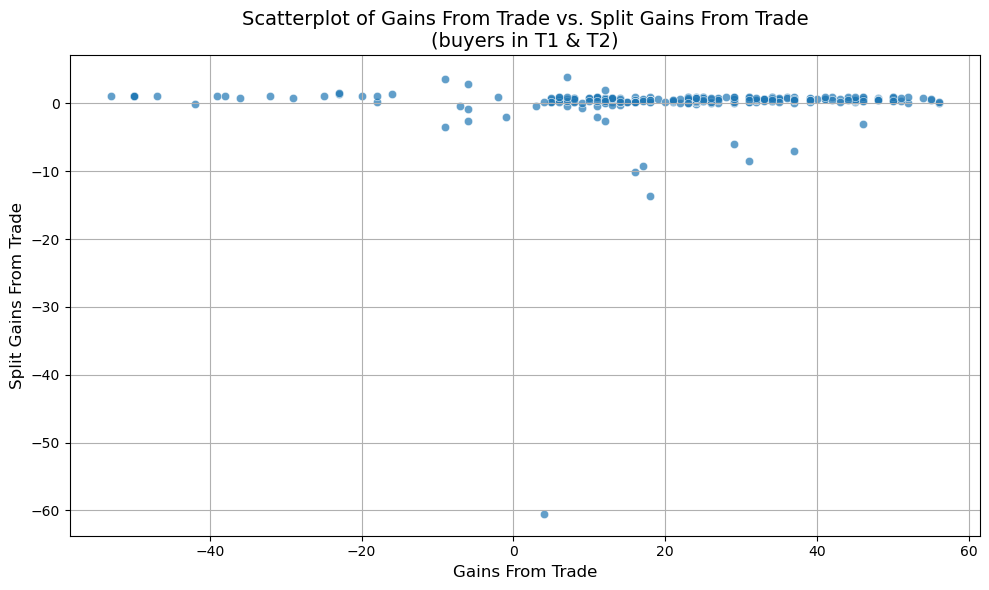

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='gains_from_trade',
    y='split_gains_from_trade',
    data=df_filtered,
    alpha=0.7
)

# Customize the plot
plt.title('Scatterplot of Gains From Trade vs. Split Gains From Trade\n(buyers in T1 & T2)', fontsize=14)
plt.xlabel('Gains From Trade', fontsize=12)
plt.ylabel('Split Gains From Trade', fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.show()


## Group Equilibrium

In [7]:
df_time = df[df["time_inconsistency_dummy"] == 0]

In [8]:

bargaining_time_full = smf.ols(formula='bargaining_time_full_sec ~ C(group_id) + C(treatment)', 
                      data=df_time).fit()

print(bargaining_time_full.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.149
Model:                                  OLS   Adj. R-squared:                  0.144
Method:                       Least Squares   F-statistic:                     32.62
Date:                      Fri, 27 Jun 2025   Prob (F-statistic):           5.12e-98
Time:                              12:15:40   Log-Likelihood:                -14064.
No. Observations:                      3190   AIC:                         2.816e+04
Df Residuals:                          3172   BIC:                         2.827e+04
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [9]:
number_of_offers = smf.ols(formula='number_of_offers ~ C(group_id) + + C(participant_code)', 
                      data=df).fit()

print(number_of_offers.summary())

                            OLS Regression Results                            
Dep. Variable:       number_of_offers   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     8.675
Date:                Fri, 27 Jun 2025   Prob (F-statistic):          7.49e-132
Time:                        12:15:40   Log-Likelihood:                -7960.1
No. Observations:                3840   AIC:                         1.618e+04
Df Residuals:                    3712   BIC:                         1.698e+04
Df Model:                         127                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

## Signaling

In [10]:
df_one_sided = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]

df_one_sided_time = df_one_sided[df_one_sided["time_inconsistency_dummy"] == 0]

df_buyer = df_one_sided[df_one_sided["participant_role"] == "Buyer"]

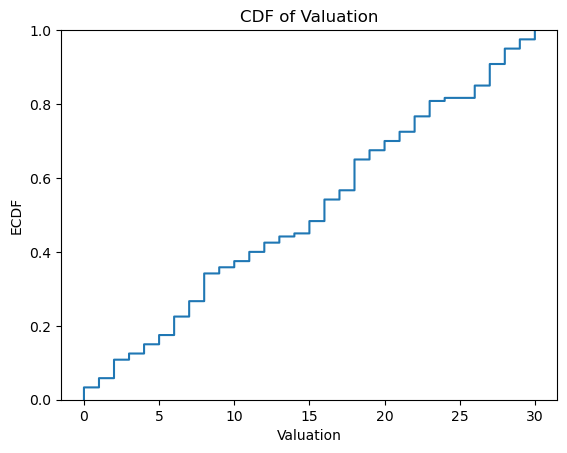

In [11]:
sns.ecdfplot(data=df_buyer, x="valuation")
plt.title('CDF of Valuation')
plt.xlabel('Valuation')
plt.ylabel('ECDF')
plt.show()

In [12]:
def plot_offer_time_vs_valuation_demeaned_t12(
        df: pd.DataFrame,
        color_scheme: list[str],
        treatment_pattern: str = "T1|T2"):
    """
    Plot demeaned offer time vs valuation with individual fixed effects removed.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing the data
    color_scheme : list[str]
        List of colors to use for different treatments
    treatment_pattern : str
        Regex pattern to filter treatments (default: all treatments)
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    """
    # Filter data for buyers and specified treatments
    df_buyer = df[
        (df["treatment"].str.contains(treatment_pattern))
    ].copy()
    
    # Calculate the mean offer_time_1 for each participant
    participant_means = df_buyer.groupby('participant_label')['offer_time_1'].mean()
    
    # Subtract the participant mean from offer_time_1 to get the fixed effect corrected offer time
    df_buyer['offer_time_1_demeaned'] = df_buyer.apply(
        lambda row: row['offer_time_1'] - participant_means[row['participant_label']], axis=1
    )
    
    # Winsorize the offer_time_1_corrected at 98%
    upper_bound = df_buyer['offer_time_1_demeaned'].quantile(0.99)
    df_buyer['offer_time_1_corrected_wins'] = df_buyer['offer_time_1_demeaned'].clip(upper=upper_bound)
    
    set_plot_theme()
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create scatter plot with treatment colors
    sns.scatterplot(
        x='valuation', 
        y='offer_time_1_corrected_wins', 
        data=df_buyer, 
        hue='participant_role', 
        alpha=0.4,
        ax=ax
    )
    
    # Add 3rd order polynomial regression line for each treatment
    for i, participant_role in enumerate(df_buyer['participant_role'].unique()):
        treatment_data = df_buyer[df_buyer['participant_role'] == participant_role]
        if len(treatment_data) > 0:
            sns.regplot(
                x='valuation', 
                y='offer_time_1_corrected_wins', 
                data=treatment_data, 
                scatter=False, 
                order=3, 
                label=f'Fit for {participant_role}',
                line_kws={"linewidth": 2},
                ci=None,  # Disable standard errors
                ax=ax
            )
    
    # Add a dotted line at y = 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    # Customize the plot
    ax.set_xlabel('Valuation')
    ax.set_ylabel('Time of First Offer (demeaned by individual fixed effect)')
    ax.legend(
    title='Role',
    frameon=True,        # ensure the frame is drawn
    facecolor='white',   # background color
    edgecolor='black',   # border color
    framealpha=1         # full opacity
    )
    finalize_plot(ax)
    
    return fig


## Buyer Only

In [13]:
df_one_sided = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]
df_one_sided_time = df_one_sided[df_one_sided["time_inconsistency_dummy"] == 0]
df_one_negotiations = df_one_sided.drop_duplicates(subset='negotiation_id', keep='first')


In [14]:
def plot_split_gains_by_treatment_role_grouped(df, color_scheme):
    """
    Create a single plot with grouped boxplots for all treatment-role combinations.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing the data
    color_scheme : list
        List of colors to use for the plot
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    """
    # Filter for one-sided treatments (T3 and T4)
    df_one_sided = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]
    
    # Create a combined label for treatment-role
    df_one_sided = df_one_sided.copy()
    df_one_sided['treatment_role'] = df_one_sided['treatment'] + ' - ' + df_one_sided['participant_role']
    
    # Drop rows with missing split_gains_from_trade
    df_plot = df_one_sided.dropna(subset=['split_gains_from_trade'])
    
    # Winsorize the split_gains_from_trade at 98%
    from scipy.stats.mstats import winsorize
    df_plot['split_gains_from_trade'] = winsorize(df_plot['split_gains_from_trade'], limits=[0.01, 0.01])
    
    set_plot_theme()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create boxplot
    bp = ax.boxplot([df_plot[df_plot['treatment_role'] == label]['split_gains_from_trade'] 
                     for label in sorted(df_plot['treatment_role'].unique())],
                    labels=sorted(df_plot['treatment_role'].unique()),
                    patch_artist=True)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], color_scheme[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Customize the plot
    ax.set_title('Split Gains from Trade by Treatment and Role')
    ax.set_ylabel('Split Gains from Trade')
    ax.set_xlabel('Treatment - Role')
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)
    
    # Adjust layout
    finalize_plot()

    
    return fig

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_66398/3688332427.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['split_gains_from_trade'] = winsorize(df_plot['split_gains_from_trade'], limits=[0.01, 0.01])
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_66398/3688332427.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_plot[df_plot['treatment_role'] == label]['split_gains_from_trade']
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_66398/416262149.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_split_gains_by_treatme

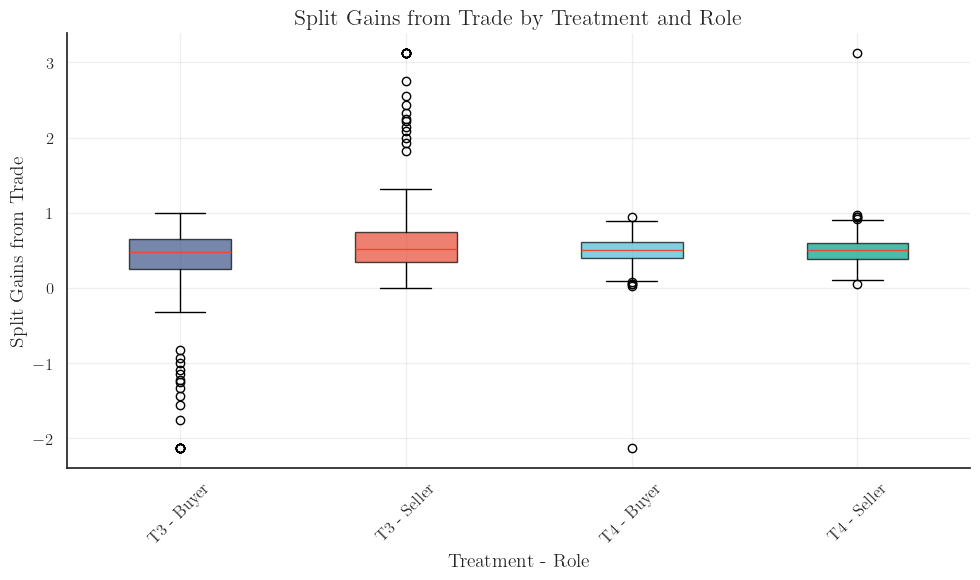

In [15]:
plot_split_gains_by_treatment_role_grouped(df_one_sided, color_scheme).show()

In [16]:
number_of_offers_df = df_one_sided

number_of_offers = smf.ols(formula='number_of_offers ~ C(TA_costs)', 
                      data=number_of_offers_df).fit(cov_type='cluster',
    cov_kwds={
        'groups': number_of_offers_df['participant_code']
    })

print(number_of_offers.summary())

                            OLS Regression Results                            
Dep. Variable:       number_of_offers   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.02822
Date:                Fri, 27 Jun 2025   Prob (F-statistic):              0.867
Time:                        12:15:41   Log-Likelihood:                -3921.7
No. Observations:                1920   AIC:                             7847.
Df Residuals:                    1918   BIC:                             7858.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.8917    

In [17]:
# Run Regressions
df_split_gains = df_one_sided.dropna(subset=['split_gains_from_trade'])
split_gains = smf.ols(formula='split_gains_from_trade ~ C(participant_role):C(TA_costs)', data=df_split_gains).fit(cov_type='cluster',
cov_kwds={
    'groups': df_split_gains['participant_code']
})
print(split_gains.summary())


                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.038
Model:                                OLS   Adj. R-squared:                  0.035
Method:                     Least Squares   F-statistic:                     3.449
Date:                    Fri, 27 Jun 2025   Prob (F-statistic):             0.0218
Time:                            12:15:41   Log-Likelihood:                -2007.5
No. Observations:                     998   AIC:                             4023.
Df Residuals:                         994   BIC:                             4043.
Df Model:                               3                                         
Covariance Type:                  cluster                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [18]:
df_one_sided_time.groupby("participant_role")["first_offer"].mean()

participant_role
Buyer     0.4426
Seller    0.5574
Name: first_offer, dtype: float64

In [19]:
df_first_offer = df_one_sided_time.dropna(subset=['first_offer'])

first_offer = smf.ols(formula='first_offer ~ C(participant_role)', 
                      data=df_first_offer).fit(cov_type='cluster',
    cov_kwds={
        'groups': df_first_offer['participant_code']
    })

print(first_offer.summary())


                            OLS Regression Results                            
Dep. Variable:            first_offer   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     3.094
Date:                Fri, 27 Jun 2025   Prob (F-statistic):             0.0839
Time:                        12:15:41   Log-Likelihood:                -1039.9
No. Observations:                1446   AIC:                             2084.
Df Residuals:                    1444   BIC:                             2094.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [20]:
print(len(df))
set_plot_theme()
# Define the piecewise function
def equilibrium_payoff(x, c=0.05, r=0.01):
    if x <= 7.72:
        return 0
    elif x >= 21.40:
        return x/2
    else:
        b = x
        return ((r*b + 2*c)/(r*21.40 + 2*c)) * (b/2 + c/r) - c/r
    

3840


In [21]:
def plot_buyer_payoff_vs_valuation(
        df: pd.DataFrame,
        color_scheme: list[str],
        treatment_t4 = "no"):
    
   
    df_buyers = df[(df["participant_role"] == "Buyer")]

    # Generate x values for the theoretical line
    x_values = np.linspace(0, 30, 1000)
    y_values = [equilibrium_payoff(x) for x in x_values]

    plt.rcParams["text.usetex"] = True
    plt.rcParams["font.family"] = "serif"
    sns.set_style("white")


    # Define a mapping from outcome labels to colors
    outcome_color_map = {
        'Player': color_scheme[0],               # Player Termination
        'Random_Termination': color_scheme[1],   # Computer Termination
        'acceptance': color_scheme[2],           # Highlight Acceptance
    }

    # Assign color values based on the outcome
    colors = df_buyers['bargaining_outcome'].map(outcome_color_map)

    fig, ax = plt.subplots(figsize=(12, 8))

    if treatment_t4 == "yes":
        plt.plot(x_values, y_values, color=color_scheme[3], linewidth=2, label='Equilibrium Payoff Model')
    
    # Add the scatter plot with custom colors
    scatter = plt.scatter(
        df_buyers['valuation'],
        df_buyers['payoff'],
        c=colors,
        alpha=0.8
    )

    plt.xlabel('Buyer Valuation (Equals Surplus) ')
    plt.ylabel('Buyer Payoff')

    # Create custom legend
    import matplotlib.lines as mlines
    legend_elements = [
        mlines.Line2D([], [], color=color_scheme[0], marker='o', linestyle='None', label='Player Termination'),
        mlines.Line2D([], [], color=color_scheme[1], marker='o', linestyle='None', label='Computer Termination'),
        mlines.Line2D([], [], color=color_scheme[2], marker='o', linestyle='None', label='Acceptance')
    ]

    if treatment_t4 == "yes":
        legend_elements.append(mlines.Line2D([], [], color=color_scheme[3], linewidth=2, label='Equilibrium Payoff Model'))

    plt.legend(handles=legend_elements, title="Bargaining Outcome")

    finalize_plot(ax)

    return fig

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_66398/2314937384.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


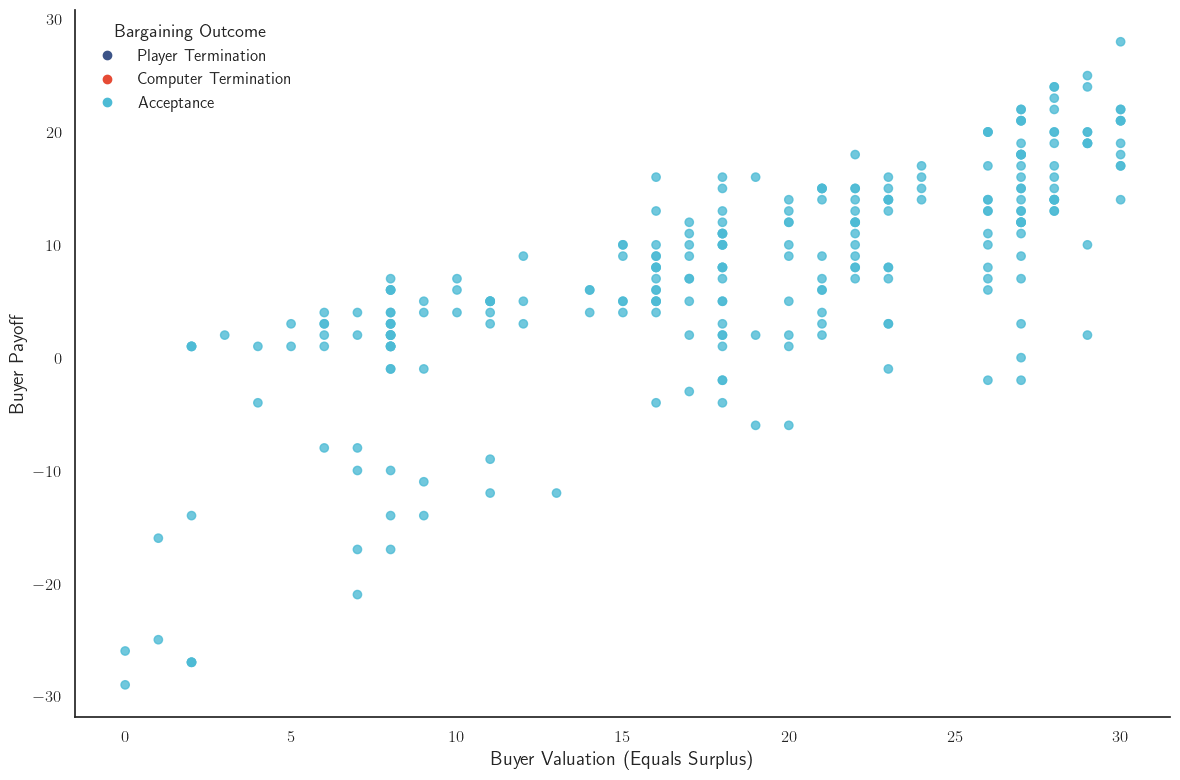

In [22]:
fig = plot_buyer_payoff_vs_valuation(df[df['treatment'] == "T3"], color_scheme, treatment_t4 = "no")

fig.show()

## Buyer Only Uncertainty

In [23]:
df_t4_time = df[(df["time_inconsistency_dummy"] == 0) & (df["treatment"] == "T4")]
df_t4 = df[df["treatment"] == "T4"]
df_t4_buyer_time = df_t4[(df_t4["participant_role"] == "Buyer") & (df_t4["time_inconsistency_dummy"] == 0)].dropna(subset=["offer_time_1"])

In [24]:
signaling_df = df_t4_buyer_time.dropna(subset=["offer_time_1"])

signaling = smf.ols(formula='offer_time_1 ~ C(valuation_bucket)', data=signaling_df).fit(cov_type='cluster',
    cov_kwds={
        'groups': df_t4_buyer_time['participant_code']
    })

print(signaling.summary())

                            OLS Regression Results                            
Dep. Variable:           offer_time_1   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.605
Date:                Fri, 27 Jun 2025   Prob (F-statistic):              0.109
Time:                        12:15:41   Log-Likelihood:                -842.18
No. Observations:                 358   AIC:                             1690.
Df Residuals:                     355   BIC:                             1702.
Df Model:                           2                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [25]:
masters = smf.ols(formula='offer_time_1 ~ valuation', data=df_t4_buyer_time).fit(cov_type='cluster',
    cov_kwds={
        'groups': df_t4_buyer_time['participant_code']
    })

print(masters.summary())

                            OLS Regression Results                            
Dep. Variable:           offer_time_1   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     4.184
Date:                Fri, 27 Jun 2025   Prob (F-statistic):             0.0601
Time:                        12:15:41   Log-Likelihood:                -842.77
No. Observations:                 358   AIC:                             1690.
Df Residuals:                     356   BIC:                             1697.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4163      0.655      5.213      0.0

In [26]:
df_t4 = df[df["treatment"] == "T4"]
df_t4_buyer_time = df_t4[(df_t4["participant_role"] == "Buyer") & (df_t4["time_inconsistency_dummy"] == 0)].dropna(subset=["offer_time_1"])

df_t34 = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]
df_t34_buyer_time = df_t34[(df_t34["participant_role"] == "Buyer") & (df_t34["time_inconsistency_dummy"] == 0)].dropna(subset=["offer_time_1"])



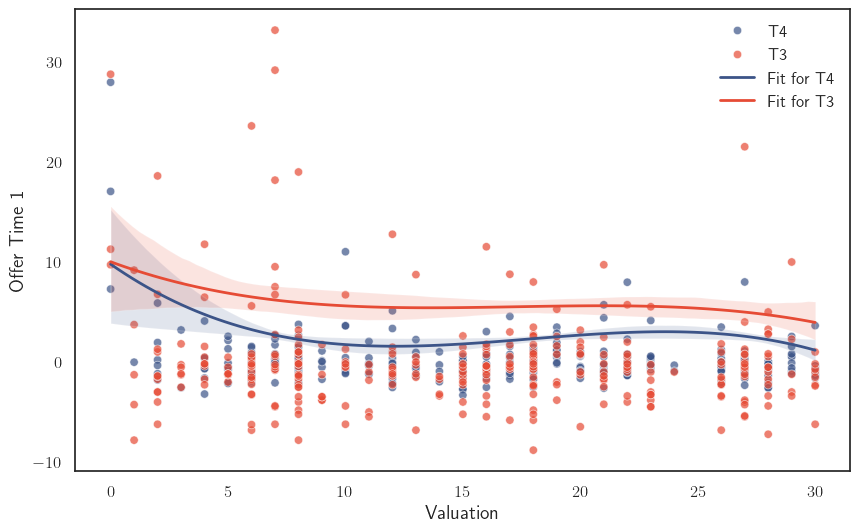

In [27]:
# Demean offer_time_1 by participant_code mean
df_t34_buyer_time['demeaned_offer_time_1'] = df_t34_buyer_time.groupby('participant_code')['offer_time_1'].transform(lambda x: x - x.mean())

plt.figure(figsize=(10, 6))
sns.scatterplot(x='valuation', y='demeaned_offer_time_1', data=df_t34_buyer_time, hue='treatment', alpha=0.7)

# Add a 3rd order polynomial regression line for each treatment
for treatment in df_t34_buyer_time['treatment'].unique():
    sns.regplot(
        x='valuation', 
        y='offer_time_1', 
        data=df_t34_buyer_time[df_t34_buyer_time['treatment'] == treatment], 
        scatter=False, 
        order=3, 
        label=f'Fit for {treatment}',
        line_kws={"linewidth": 2}
    )

# Customize the plot
plt.xlabel('Valuation')
plt.ylabel('Offer Time 1')
plt.legend()
plt.show()

In [28]:
suspect = df[df['participant_code'] == "sf12dllp"]



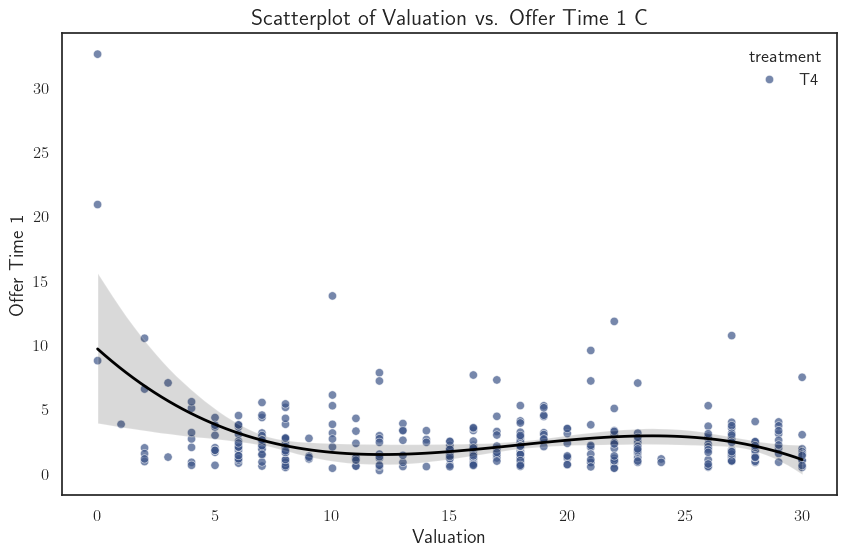

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='valuation', y='offer_time_1', data=df_t4_buyer_time, hue='treatment', alpha=0.7)
# Add a 3rd order polynomial regression line
sns.regplot(x='valuation', y='offer_time_1', data=df_t4_buyer_time, scatter=False, color='black', order=3, line_kws={"linewidth": 2})

# Customize the plot
plt.title('Scatterplot of Valuation vs. Offer Time 1 C')
plt.xlabel('Valuation')
plt.ylabel('Offer Time 1')
plt.show()

# Time Graph

In [30]:
color_scheme =  ["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"]

In [31]:
test_error = df[df['offer_time_1'] > df["bargaining_time_full_sec"]]

In [32]:
df_t4 = df[df["treatment"] == "T4"]
df_t4_buyer = df_t4[df_t4["participant_role"] == "Buyer"].dropna(subset=["offer_time_1"])

df_t3 = df[df["treatment"] == "T3"]
df_t3_buyer = df_t3[df_t3["participant_role"] == "Buyer"].dropna(subset=["offer_time_1"])

df_t34 = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]
df_t34_buyer = df_t34[df_t34["participant_role"] == "Buyer"].dropna(subset=["offer_time_1"])



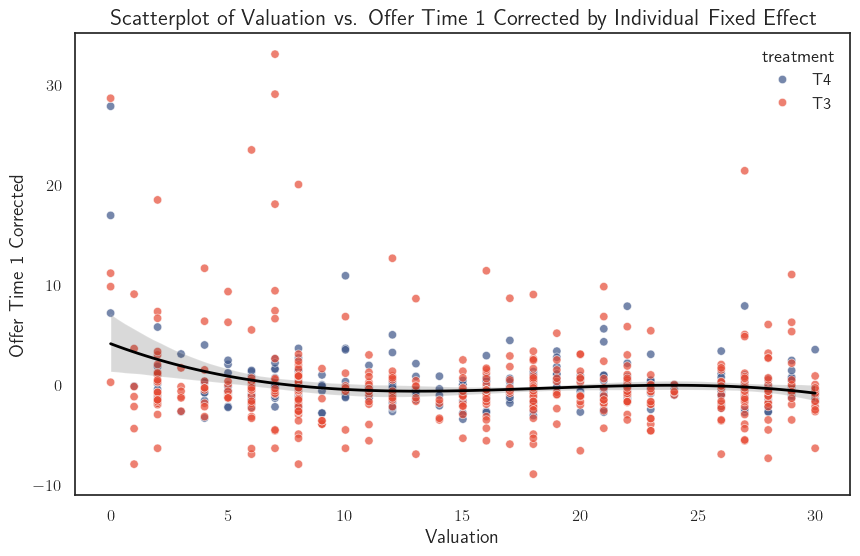

In [33]:

# Calculate the mean offer_time_1 for each participant
participant_means = df_t34_buyer.groupby('participant_label')['offer_time_1'].mean()

# Subtract the participant mean from offer_time_1 to get the fixed effect corrected offer time
df_t34_buyer['offer_time_1_corrected'] = df_t34_buyer.apply(
    lambda row: row['offer_time_1'] - participant_means[row['participant_label']], axis=1
)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='valuation', y='offer_time_1_corrected', data=df_t34_buyer, hue='treatment', alpha=0.7)
# Add a 3rd order polynomial regression line
sns.regplot(x='valuation', y='offer_time_1_corrected', data=df_t34_buyer, scatter=False, color='black', order=3, line_kws={"linewidth": 2})

# Customize the plot
plt.title('Scatterplot of Valuation vs. Offer Time 1 Corrected by Individual Fixed Effect')
plt.xlabel('Valuation')
plt.ylabel('Offer Time 1 Corrected')
plt.show()


In [34]:
test = df_t34[df_t34['offer_time_1'] > 40]

In [35]:
def plot_buyer_vals_vs_offer_time_1(df_t4_buyer, color_scheme):
    # Define a mapping from outcome labels to colors
    outcome_color_map = {
        'Player': color_scheme[0],               # Player Termination
        'Random_Termination': color_scheme[1],   # Computer Termination
        'acceptance': color_scheme[2],           # Highlight Acceptance
    }

    # Winsorize 'offer_time_1' at the 95th percentile
    # offer_time_95th = df_t4_buyer['offer_time_1'].quantile(0.95)
    # df_t4_buyer['offer_time_1'] = np.where(df_t4_buyer['offer_time_1'] > offer_time_95th, offer_time_95th, df_t4_buyer['offer_time_1'])

    # Assign color values based on the outcome
    colors = df_t4_buyer['bargaining_outcome'].astype("category").map(outcome_color_map)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='valuation', y='offer_time_1', data=df_t4_buyer, c=colors, alpha=0.7)
    # Add a 3rd order polynomial regression line
    sns.regplot(x='valuation', y='offer_time_1', data=df_t4_buyer, scatter=False, color='black', order=3, line_kws={"linewidth": 2})

    # Customize the plot
    plt.title('Scatterplot of Valuation vs. Offer Time 1')
    plt.xlabel('Valuation')
    plt.ylabel('Offer Time 1')
    plt.show()


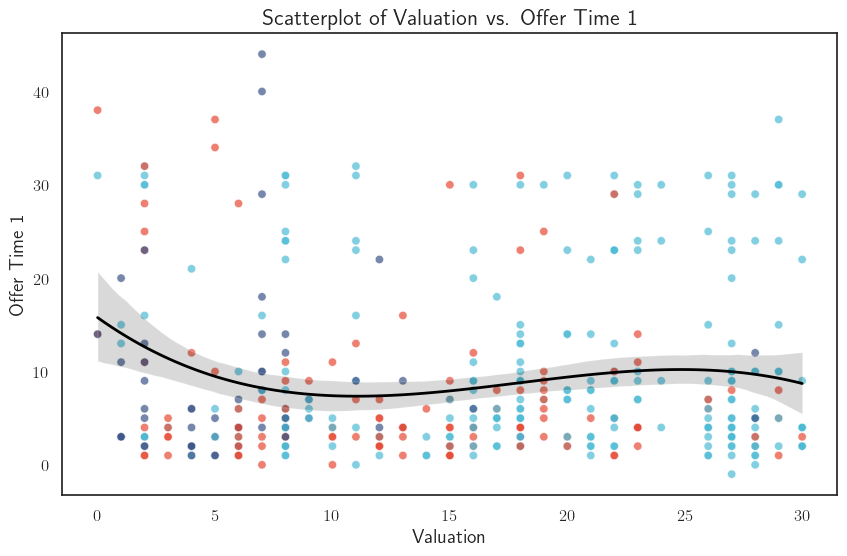

In [36]:
plot_buyer_vals_vs_offer_time_1(df_t3_buyer, color_scheme)

In [37]:
def calculate_time_equilibrium(b, c=0.05, r=0.01):
    if b <= 7.72 or b >= 21.40:
        return 0
    else:
        return 1/0.01 * np.log((b +10) / (21.40 +10))


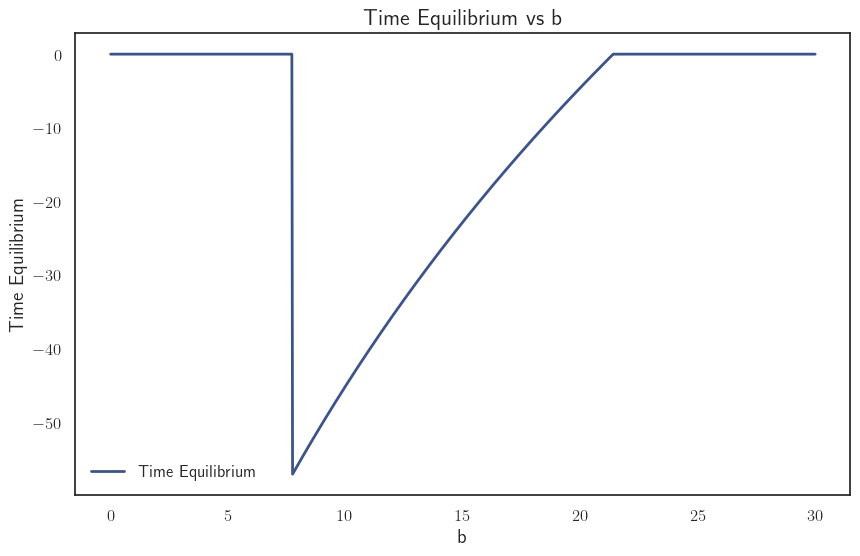

In [38]:
# Generate values for b between 0 and 30
b_values = np.linspace(0, 30, 1000)
time_equilibrium_values = [calculate_time_equilibrium(b) for b in b_values]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(b_values, time_equilibrium_values, label='Time Equilibrium')
plt.xlabel('b')
plt.ylabel('Time Equilibrium')
plt.title('Time Equilibrium vs b')
plt.legend()
plt.show()


# Central Efficiency Graph

In [39]:
df_positive = df[df["gains_from_trade_dummy"] == 1]
df_positive_neg = df_positive.drop_duplicates(subset='negotiation_id', keep='first')

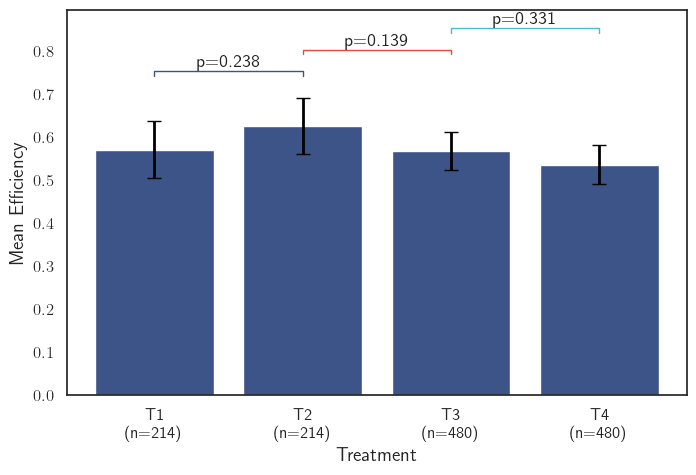

In [40]:
# Replace 'df' with your actual DataFrame name
df_plot = df_positive_neg

# Compute group means, standard errors, 95% CIs, and sample sizes
group = df_plot.groupby('treatment')['efficiency']
means = group.mean()
ses = group.sem()
ci95 = 1.96 * ses
ns = group.size()

# Perform pairwise t-tests for adjacent treatments
pairs = [('T1', 'T2'), ('T2', 'T3'), ('T3', 'T4')]
pvals = {}
for a, b in pairs:
    d1 = df_plot[df_plot['treatment'] == a]['efficiency']
    d2 = df_plot[df_plot['treatment'] == b]['efficiency']
    _, p = ttest_ind(d1, d2, equal_var=False, nan_policy='omit')
    pvals[(a, b)] = p

# Create bar plot with 95% CIs
fig, ax = plt.subplots()
ax.bar(means.index, means.values, yerr=ci95.values, capsize=5)

# Annotate p-values above pairs
y_base = means.max() + ci95.max() + 0.05
step = 0.05
for i, (a, b) in enumerate(pairs):
    x1 = list(means.index).index(a)
    x2 = list(means.index).index(b)
    y = y_base + i * step
    ax.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1)
    ax.text((x1 + x2) / 2, y + 0.01, f'p={pvals[(a, b)]:.3f}', ha='center', va='bottom')

# Label axes and include sample size in x-tick labels
ax.set_xlabel('Treatment')
ax.set_ylabel('Mean Efficiency')
labels = [f'{t}\n(n={ns[t]})' for t in means.index]
ax.set_xticks(range(len(means)))
ax.set_xticklabels(labels)

plt.show()

# Who Are the Master Negotiators?

In [41]:
df_master = df.dropna(subset=['first_offer_split', 'large_gains_from_trade_indicator'])

In [42]:
masters = smf.ols(formula='large_gains_from_trade_indicator ~ C(information_asymmetry):C(TA_costs) + first_offer + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points + bargaining_time_full_sec', data=df_master).fit(cov_type='cluster',
    cov_kwds={
        'groups': df_master['participant_code']
    })

print(masters.summary())

                                   OLS Regression Results                                   
Dep. Variable:     large_gains_from_trade_indicator   R-squared:                       0.368
Model:                                          OLS   Adj. R-squared:                  0.366
Method:                               Least Squares   F-statistic:                 4.499e+04
Date:                              Fri, 27 Jun 2025   Prob (F-statistic):          9.34e-205
Time:                                      12:15:44   Log-Likelihood:                -640.23
No. Observations:                              1717   AIC:                             1296.
Df Residuals:                                  1709   BIC:                             1340.
Df Model:                                         7                                         
Covariance Type:                            cluster                                         
                                                              coef    

In [43]:
masters_with_offer_size = smf.ols(formula='large_gains_from_trade_indicator ~ C(information_asymmetry):C(TA_costs) + first_offer + first_offer_split + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points', data=df_master).fit()

print(masters_with_offer_size.summary())

                                   OLS Regression Results                                   
Dep. Variable:     large_gains_from_trade_indicator   R-squared:                       0.448
Model:                                          OLS   Adj. R-squared:                  0.446
Method:                               Least Squares   F-statistic:                     198.0
Date:                              Fri, 27 Jun 2025   Prob (F-statistic):          3.76e-215
Time:                                      12:15:44   Log-Likelihood:                -524.50
No. Observations:                              1717   AIC:                             1065.
Df Residuals:                                  1709   BIC:                             1109.
Df Model:                                         7                                         
Covariance Type:                          nonrobust                                         
                                                              coef    

# Comparing all Treatments

In [44]:
all_negotiations = df.drop_duplicates(subset='negotiation_id', keep='first')

In [45]:
efficiency = smf.ols(formula='efficiency ~ C(information_asymmetry) + positive_gains_symmetric_treatment + C(information_asymmetry):small_gains_from_trade_indicator', data=all_negotiations).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     142.1
Date:                Fri, 27 Jun 2025   Prob (F-statistic):          1.96e-106
Time:                        12:15:44   Log-Likelihood:                -1022.6
No. Observations:                1920   AIC:                             2055.
Df Residuals:                    1915   BIC:                             2083.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [46]:
behavioral_efficiency = smf.ols(formula='efficiency ~ C(information_asymmetry) + positive_gains_symmetric_treatment + C(information_asymmetry):small_gains_from_trade_indicator + ultimatum_indicator + C(TA_costs) + risk_elicitation_choice + time_preference_switching_points', data=df).fit()

print(behavioral_efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     143.7
Date:                Fri, 27 Jun 2025   Prob (F-statistic):          6.82e-212
Time:                        12:15:44   Log-Likelihood:                -2040.1
No. Observations:                3840   AIC:                             4098.
Df Residuals:                    3831   BIC:                             4155.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [47]:
#Create Table
pystout(
models=[efficiency, behavioral_efficiency],
file="output.tex",
digits=2,
endog_names=['Efficiency', "Efficiency"],
varlabels={'const':'Constant','first_offer':'First Offer', 'split_gains_from_trade':'Split Gains from Trade', 'efficiency':'Efficiency', 'agreement_dummy':'Dummy Agreement', 'C(participant_role)[T.Seller]':'Seller', 'C(TA_costs)[T.0.05]':'TA Costs $= 0.05$', 'gains_from_trade':'Gains from Trade', 
    "C(information_asymmetry)[one-sided]:small_gains_from_trade_indicator": "One-sided $\\times$ Small Gains from Trade",
    "C(information_asymmetry)[two-sided]:small_gains_from_trade_indicator": "Two-sided $\\times$ Small Gains from Trade",
    "C(information_asymmetry)[one-sided]:positive_gains_symmetric_treatment": "One-sided $\\times$ Positive Gains from Trade",
    "C(information_asymmetry)[two-sided]:positive_gains_symmetric_treatment": "Two-sided $\\times$ Positive Gains from Trade",
    "C(information_asymmetry)[one-sided]:ultimatum_indicator": "One-sided $\\times$ Ultimatum Indicator",
    "C(information_asymmetry)[two-sided]:ultimatum_indicator": "Two-sided $\\times$ Ultimatum Indicator",
    "ultimatum_indicator": "Ultimatum Offer $>50\%$",
    "risk_elicitation_choice": "Risk Aversion",
    "time_preference_switching_points": "Time Preference",
    },
stars={.1:'*',.05:'**',.01:'***'},
modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
)


<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_66398/615490991.py:14: SyntaxWarning: invalid escape sequence '\%'
  "ultimatum_indicator": "Ultimatum Offer $>50\%$",
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_66398/615490991.py:19: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


In [48]:
agreement = smf.ols(formula='agreement_dummy ~ C(information_asymmetry) + positive_gains_symmetric_treatment + small_gains_from_trade_indicator', data=all_negotiations).fit()

print(agreement.summary())

                            OLS Regression Results                            
Dep. Variable:        agreement_dummy   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     310.5
Date:                Fri, 27 Jun 2025   Prob (F-statistic):          2.88e-164
Time:                        12:15:44   Log-Likelihood:                -976.43
No. Observations:                1920   AIC:                             1961.
Df Residuals:                    1916   BIC:                             1983.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [49]:
behavioral_agreement = smf.ols(formula='agreement_dummy ~ C(information_asymmetry) + positive_gains_symmetric_treatment + small_gains_from_trade_indicator + ultimatum_indicator + C(TA_costs) + risk_elicitation_choice + time_preference_switching_points', data=all_negotiations).fit()

print(behavioral_agreement.summary())

                            OLS Regression Results                            
Dep. Variable:        agreement_dummy   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     136.0
Date:                Fri, 27 Jun 2025   Prob (F-statistic):          1.03e-162
Time:                        12:15:44   Log-Likelihood:                -968.97
No. Observations:                1920   AIC:                             1954.
Df Residuals:                    1912   BIC:                             1998.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Symmetric Uncertainty

In [56]:
df_symmetric = df[(df["treatment"] == "T1") | (df["treatment"] == "T2")]
df_symmetric_buyer = df_symmetric[df_symmetric["participant_role"] == "Buyer"]
df_symmetric_time = df_symmetric[df_symmetric["time_inconsistency_dummy"] == 0]
df_symmetric_negotiations = df_symmetric.drop_duplicates(subset='negotiation_id', keep='first')



In [58]:
first_offer_regression = smf.ols(formula='first_offer ~ C(participant_role)', data=df_symmetric_time).fit()

print(first_offer_regression.summary())

                            OLS Regression Results                            
Dep. Variable:            first_offer   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     72.79
Date:                Fri, 27 Jun 2025   Prob (F-statistic):           3.65e-17
Time:                        12:17:01   Log-Likelihood:                -996.53
No. Observations:                1422   AIC:                             1997.
Df Residuals:                    1420   BIC:                             2008.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [52]:
number_of_offers_regression = smf.ols(formula='number_of_offers ~ C(participant_role)', data=df_symmetric).fit()

print(number_of_offers_regression.summary())

                            OLS Regression Results                            
Dep. Variable:       number_of_offers   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3380
Date:                Fri, 27 Jun 2025   Prob (F-statistic):              0.561
Time:                        12:15:44   Log-Likelihood:                -4461.9
No. Observations:                1920   AIC:                             8928.
Df Residuals:                    1918   BIC:                             8939.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

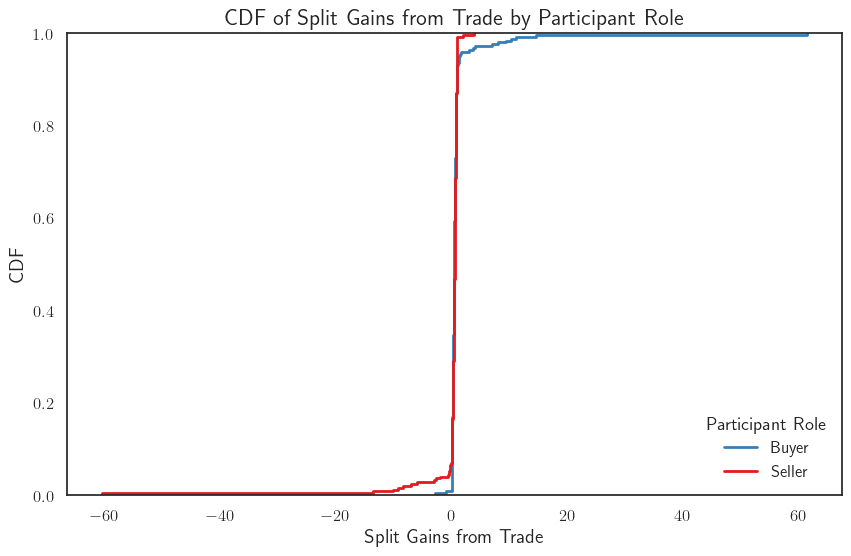

In [53]:

# Plot CDF for 'split_gains_from_trade' separately by participant role
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_symmetric[df_symmetric["gains_from_trade"] > 0], x='split_gains_from_trade', hue='participant_role', palette='Set1')
plt.title('CDF of Split Gains from Trade by Participant Role')
plt.xlabel('Split Gains from Trade')
plt.ylabel('CDF')
plt.legend(title='Participant Role', loc='lower right', labels=df_symmetric['participant_role'].unique())
plt.show()

In [54]:
def plot_buyer_payoff_vs_gains_from_trade_t12(
        df: pd.DataFrame,
        color_scheme: list[str], 
        treatment_pattern: str = "T1|T2"):
    
    df_buyers = df[df["participant_role"].str.contains("Buyer") & df["treatment"].str.contains(treatment_pattern)]

    # Generate x values for the theoretical line
    x_values = np.linspace(0, 60, 1000)

    # Define a mapping from outcome labels to colors
    outcome_color_map = {
        'Player': color_scheme[0],               # Player Termination
        'Random_Termination': color_scheme[1],   # Computer Termination
        'acceptance': color_scheme[2],           # Highlight Acceptance
    }

    # Assign color values based on the outcome
    colors = df_buyers['bargaining_outcome'].map(outcome_color_map)

    set_plot_theme()

    fig, ax = plt.subplots(figsize=(12,8))
     
    # Add the scatter plot with custom colors
    scatter = plt.scatter(
        df_buyers['gains_from_trade'],
        df_buyers['payoff'],
        c=colors,
        alpha=0.8
    )
    # Create custom legend
    import matplotlib.lines as mlines
    legend_elements = [
        mlines.Line2D([], [], color=color_scheme[0], marker='o', linestyle='None', label='Player Termination'),
        mlines.Line2D([], [], color=color_scheme[1], marker='o', linestyle='None', label='Computer Termination'),
        mlines.Line2D([], [], color=color_scheme[2], marker='o', linestyle='None', label='Acceptance')
    ]

    plt.plot(x_values, 0.5*x_values, color=color_scheme[3], linestyle='--', linewidth=2, label='Equal Split Line')
    legend_elements.append(mlines.Line2D([], [], color=color_scheme[3], linestyle='--', linewidth=2, label='Equal Split Line'))
     
    plt.xlim(-60, 60)  # Set x-axis limits

    plt.xlabel('Gains from Trade')
    plt.ylabel('Buyer Payoff')

    plt.legend(handles=legend_elements, title="Bargaining Outcome")

    finalize_plot(ax)

    return fig

In [55]:
plot_buyer_payoff_vs_gains_from_trade(df_symmetric, color_scheme).show()

NameError: name 'plot_buyer_payoff_vs_gains_from_trade' is not defined

In [40]:
split_gains_regression = smf.ols(formula='split_gains_from_trade ~ C(participant_role)', data=df_symmetric).fit()

print(split_gains_regression.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.000
Model:                                OLS   Adj. R-squared:                 -0.002
Method:                     Least Squares   F-statistic:                   0.03397
Date:                    Thu, 26 Jun 2025   Prob (F-statistic):              0.854
Time:                            11:28:55   Log-Likelihood:                -258.93
No. Observations:                     462   AIC:                             521.9
Df Residuals:                         460   BIC:                             530.1
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [91]:
def plot_split_gains_by_treatment_role_grouped_t12(df, color_scheme):
    """
    Create a single plot with grouped boxplots for all treatment-role combinations.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing the data
    color_scheme : list
        List of colors to use for the plot
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    """
    # Filter for one-sided treatments (T3 and T4)
    df_one_sided = df[(df["treatment"] == "T1") | (df["treatment"] == "T2") & (df["gains_from_trade"] > 0)]
    
    # Create a combined label for treatment-role
    df_one_sided = df_one_sided.copy()
    df_one_sided['treatment_role'] = df_one_sided['treatment'] + ' - ' + df_one_sided['participant_role']
    
    # Drop rows with missing split_gains_from_trade
    df_plot = df_one_sided.dropna(subset=['split_gains_from_trade'])
    
    # Winsorize the split_gains_from_trade at 98%
    from scipy.stats.mstats import winsorize
    df_plot['split_gains_from_trade'] = winsorize(df_plot['split_gains_from_trade'], limits=[0.01, 0.01])
    
    set_plot_theme()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create boxplot
    bp = ax.boxplot([df_plot[df_plot['treatment_role'] == label]['split_gains_from_trade'] 
                     for label in sorted(df_plot['treatment_role'].unique())],
                    labels=sorted(df_plot['treatment_role'].unique()),
                    patch_artist=True)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], color_scheme[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Customize the plot
    ax.set_title('Split Gains from Trade by Treatment and Role')
    ax.set_ylabel('Split Gains from Trade')
    ax.set_xlabel('Treatment - Role')
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)
    
    # Adjust layout
    finalize_plot()

    
    return fig

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_29850/1991721330.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['split_gains_from_trade'] = winsorize(df_plot['split_gains_from_trade'], limits=[0.01, 0.01])
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_29850/1991721330.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_plot[df_plot['treatment_role'] == label]['split_gains_from_trade']


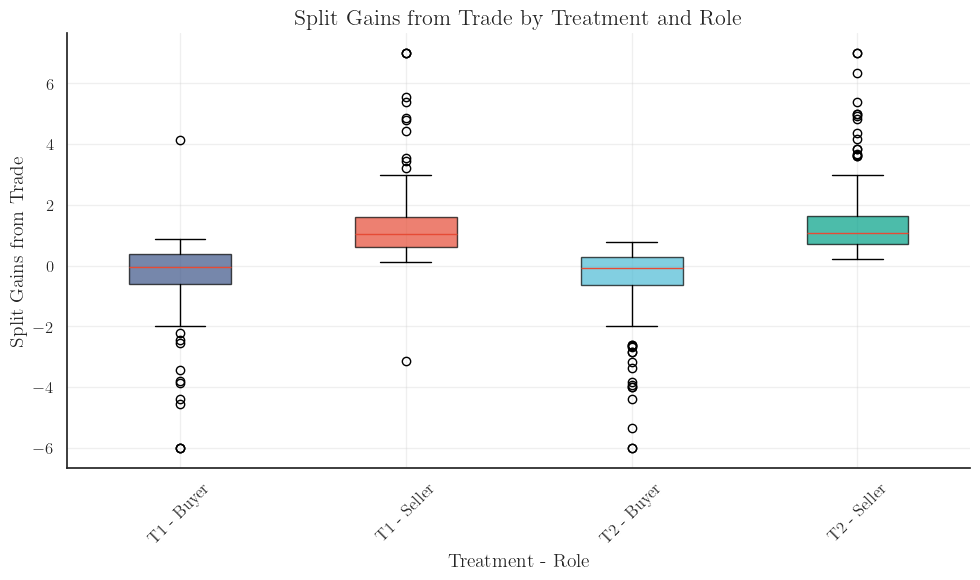

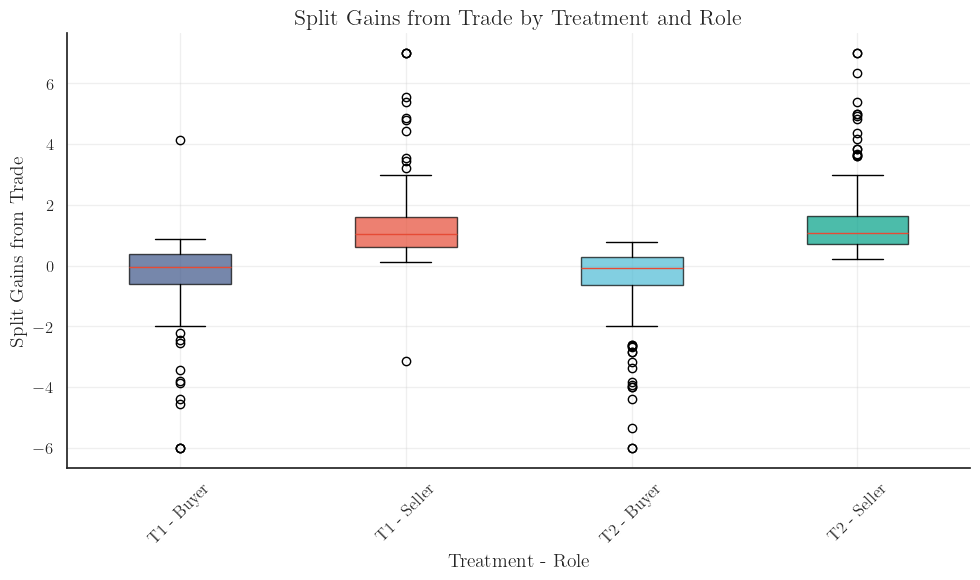

In [ ]:
plot_split_gains_by_treatment_role_grouped_t12(df, color_scheme)

In [79]:
gains_from_trade_splot = smf.ols(formula='split_gains_from_trade ~ C(participant_role):first_offer', data=df_asymmetric).fit()

print(gains_from_trade_splot.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.024
Model:                                OLS   Adj. R-squared:                  0.020
Method:                     Least Squares   F-statistic:                     5.678
Date:                    Thu, 26 Jun 2025   Prob (F-statistic):            0.00367
Time:                            10:46:46   Log-Likelihood:                -1272.5
No. Observations:                     462   AIC:                             2551.
Df Residuals:                         459   BIC:                             2563.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [81]:
first_mover_advantage = smf.ols(formula='split_gains_from_trade ~ number_of_offers', data=df_asymmetric).fit()

print(first_mover_advantage.summary())


                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.000
Model:                                OLS   Adj. R-squared:                 -0.002
Method:                     Least Squares   F-statistic:                   0.02619
Date:                    Thu, 26 Jun 2025   Prob (F-statistic):              0.871
Time:                            10:48:28   Log-Likelihood:                -1278.1
No. Observations:                     462   AIC:                             2560.
Df Residuals:                         460   BIC:                             2569.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


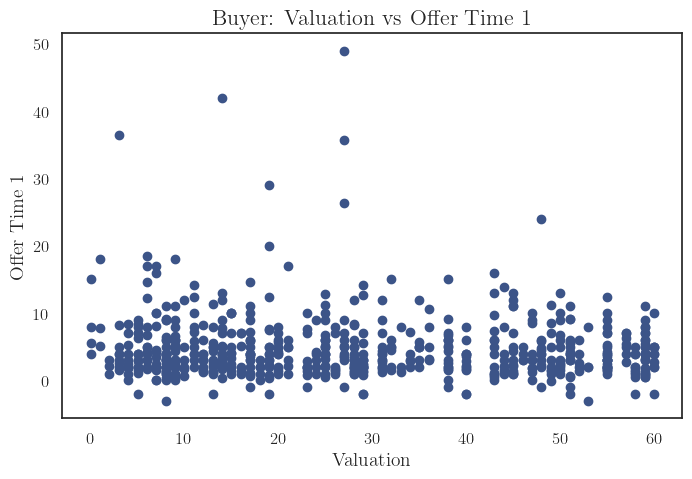

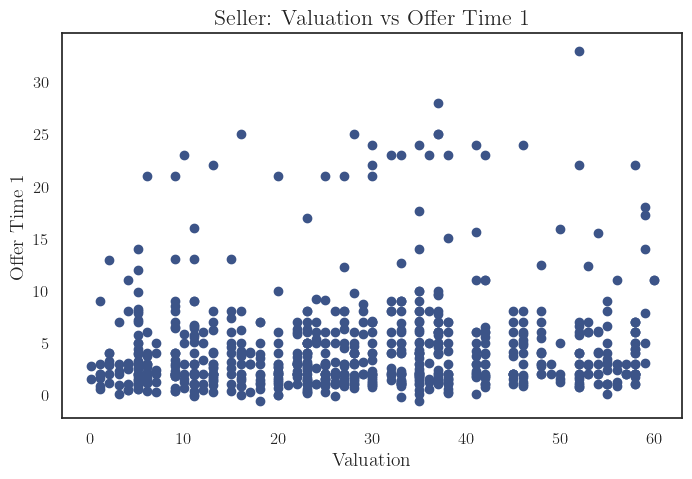

In [43]:
# Scatterplots for Buyer and Seller separately
for role in ['Buyer', 'Seller']:
    subset = df_asymmetric[df_asymmetric['participant_role'] == role]
    plt.figure()
    plt.scatter(subset['valuation'], subset['offer_time_1'])
    plt.xlabel('Valuation')
    plt.ylabel('Offer Time 1')
    plt.title(f'{role}: Valuation vs Offer Time 1')
    plt.show()

In [42]:
silent_signaling = smf.ols(formula='offer_time_1 ~ C(participant_role):valuation', data=df_asymmetric).fit()

print(silent_signaling.summary())

                            OLS Regression Results                            
Dep. Variable:           offer_time_1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9041
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.405
Time:                        16:33:22   Log-Likelihood:                -4057.9
No. Observations:                1358   AIC:                             8122.
Df Residuals:                    1355   BIC:                             8137.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [56]:
df_asymmetric = df[(df["treatment"] == "T1") | (df["treatment"] == "T2")]
df_asymmetric_negotiations = df_asymmetric.drop_duplicates(subset='negotiation_id', keep='first')

efficiency = smf.ols(formula='efficiency ~ C(TA_costs)', data=df_asymmetric_negotiations).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5109
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.475
Time:                        10:42:59   Log-Likelihood:                -279.29
No. Observations:                 392   AIC:                             562.6
Df Residuals:                     390   BIC:                             570.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5612    

## Check MAin Behavcioral Hypotheses

In [7]:
import statsmodels.formula.api as smf
import pandas as pd

behavioral = smf.ols(formula='payoff ~ C(participant_role) + C(information_asymmetry) + C(TA_costs) + C(TA_costs) * C(information_asymmetry) + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points + first_offer + valuation', data=df).fit()

print(behavioral.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     14.46
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           3.60e-23
Time:                        09:33:53   Log-Likelihood:                -10851.
No. Observations:                3134   AIC:                         2.172e+04
Df Residuals:                    3124   BIC:                         2.178e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [8]:
efficiency = smf.ols(formula='efficiency ~ C(information_asymmetry) + C(TA_costs) + C(TA_costs) * C(information_asymmetry) + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points + first_offer + valuation', data=df).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     27.80
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           4.22e-42
Time:                        09:33:53   Log-Likelihood:                -1912.1
No. Observations:                3134   AIC:                             3842.
Df Residuals:                    3125   BIC:                             3897.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

## Now, I check one sided uncertainty

In [9]:
df_one_sided = df[(df["treatment"] == "T3") | (df["treatment"] == "T4")]

df_one_negotiations = df_one_sided.drop_duplicates(subset='negotiation_id', keep='first')

In [10]:
df_one_negotiations.shape

(868, 115)

Percentage below 0: 1.56%
Percentage above 1: 1.56%


<Axes: >

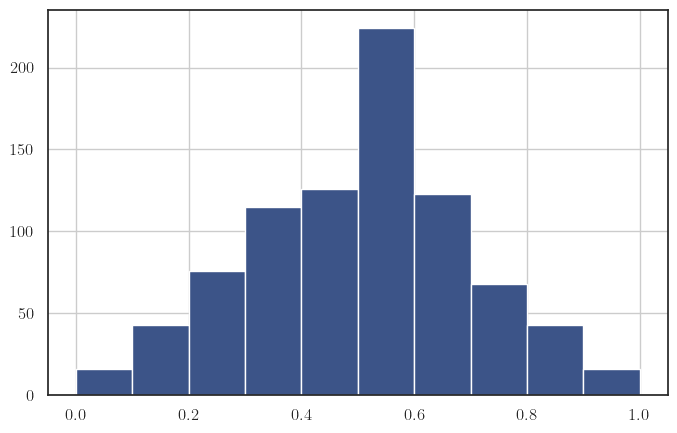

In [11]:
below_zero = (df_one_sided["split_gains_from_trade"] < 0).mean() * 100
above_one = (df_one_sided["split_gains_from_trade"] > 1).mean() * 100

print(f"Percentage below 0: {below_zero:.2f}%")
print(f"Percentage above 1: {above_one:.2f}%")

df_one_sided["split_gains_from_trade"].hist(range=(0, 1))

In [12]:
first_offer = smf.ols(formula='first_offer ~ C(participant_role)', data=df_one_sided).fit()

print(first_offer.summary())

                            OLS Regression Results                            
Dep. Variable:            first_offer   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     37.07
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           1.42e-09
Time:                        09:33:58   Log-Likelihood:                -1134.2
No. Observations:                1588   AIC:                             2272.
Df Residuals:                    1586   BIC:                             2283.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [13]:
split_gains = smf.ols(formula='split_gains_from_trade ~ C(participant_role) + C(TA_costs)', data=df_one_sided).fit()

print(split_gains.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.016
Model:                                OLS   Adj. R-squared:                  0.014
Method:                     Least Squares   F-statistic:                     7.512
Date:                    Wed, 18 Jun 2025   Prob (F-statistic):           0.000582
Time:                            09:34:00   Log-Likelihood:                -1323.9
No. Observations:                     904   AIC:                             2654.
Df Residuals:                         901   BIC:                             2668.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [14]:
payoff = smf.ols(formula='payoff ~ C(participant_role) + C(TA_costs)', data=df_one_sided).fit()

print(payoff.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.561
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.210
Time:                        09:34:06   Log-Likelihood:                -2872.4
No. Observations:                 868   AIC:                             5751.
Df Residuals:                     865   BIC:                             5765.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [15]:
efficiency = smf.ols(formula='efficiency ~  C(TA_costs) + gains_from_trade', data=df_one_negotiations).fit()

print(efficiency.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     98.39
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           3.16e-39
Time:                        09:34:23   Log-Likelihood:                -537.69
No. Observations:                 868   AIC:                             1081.
Df Residuals:                     865   BIC:                             1096.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.1827    

In [19]:
agreement = smf.ols(formula='agreement_dummy ~ C(TA_costs)', data=df_one_sided).fit()

print(agreement.summary())

                            OLS Regression Results                            
Dep. Variable:        agreement_dummy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3319
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.565
Time:                        08:50:18   Log-Likelihood:                -1258.6
No. Observations:                1736   AIC:                             2521.
Df Residuals:                    1734   BIC:                             2532.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5253    

In [23]:
bargaining_duration = smf.ols(formula='bargaining_time_full_sec ~ C(TA_costs)', data=df_one_sided).fit()

print(bargaining_duration.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                     1.316
Date:                      Wed, 18 Jun 2025   Prob (F-statistic):              0.251
Time:                              08:51:22   Log-Likelihood:                -7550.8
No. Observations:                      1736   AIC:                         1.511e+04
Df Residuals:                          1734   BIC:                         1.512e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [25]:
pystout(models=[first_offer, split_gains, efficiency, agreement],
    file='sandbox.tex',
    addnotes=['\\textit{Notes:} These regressions are run on the data from the treatments with asymmetric uncertainty. Dummy First Offer is indicator equal to 1 if the player has made the first offer, split gains from trade is percentage of the surplus the player extracts from a successfull trade (we exclude transaction costs for this measure), efficiency is indicator equal to 1 if an agreement was reached and 0 otherwise (surplus is always at leas zero in the considered treatmends) and Dummy Agreement is an indicator equal to 1 if an agreement was reached.'],
    digits=2,
    endog_names=['Dummy First Offer', "Split Gains from Trade", "Efficiency", "Dummy Agreement"],
    varlabels={'const':'Constant','first_offer':'First Offer', 'split_gains_from_trade':'Split Gains from Trade', 'efficiency':'Efficiency', 'agreement_dummy':'Dummy Agreement', 'C(participant_role)[T.Seller]':'Seller', 'C(TA_costs)[T.0.05]':'TA Costs $= 0.05$', 'gains_from_trade':'Gains from Trade'},
    modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
    )

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_88673/80041063.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


## I would like to look at two sided uncertainty. 
- first mover advantage?
- Longer silence signals lower valuation
- Adding transaction costs

In [34]:
df_twosided = df[(df["treatment"] == "T2") | (df["treatment"] == "T1")]
df_twosided_time = df_twosided[df_twosided["time_inconsistency_dummy"] == 0]

In [75]:
sum(df_twosided_time["offer_time_1"] < -0.05)

21

In [76]:
error = df_twosided_time[df_twosided_time["offer_time_1"] < -0.05]

In [64]:


df_regression = df_twosided_time.dropna(subset=["first_offer"])

signaling = smf.ols(formula='offer_time_1 ~ C(participant_role):valuation', data=df_regression).fit()

# 4. Examine the results
print(signaling.summary())

                            OLS Regression Results                            
Dep. Variable:           offer_time_1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6181
Date:                Wed, 25 Jun 2025   Prob (F-statistic):              0.539
Time:                        11:10:33   Log-Likelihood:                -3268.6
No. Observations:                1181   AIC:                             6543.
Df Residuals:                    1178   BIC:                             6558.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

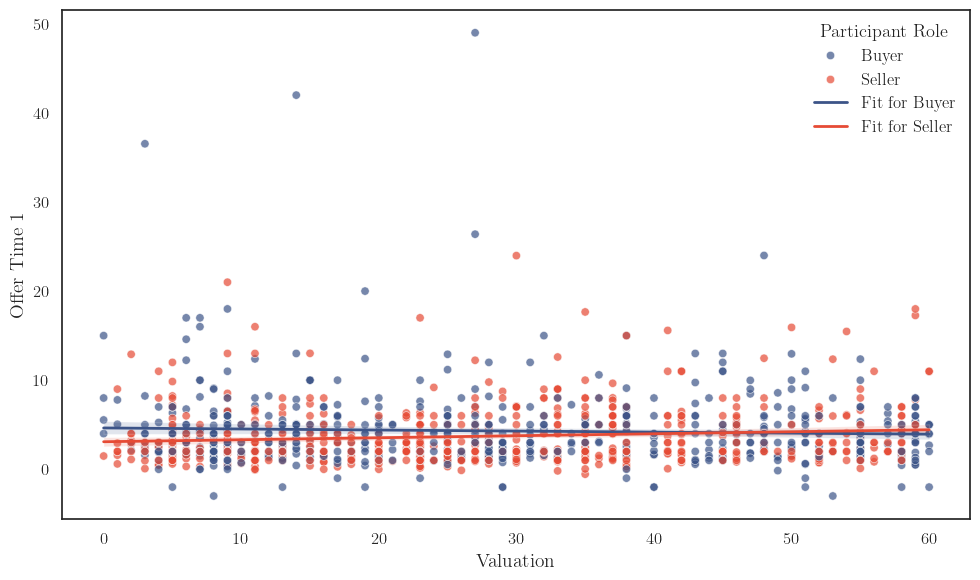

In [ ]:
# Scatterplot: valuation vs. offer_time_1, colored by participant_role

# Create the figure + axes
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x='valuation',
    y='offer_time_1',
    hue='participant_role',
    data=df_twosided_time,
    alpha=0.7,
    ax=ax
)

# Add 1st order polynomial fits for each participant role
for role in df_twosided_time['participant_role'].unique():
    sns.regplot(
        x='valuation',
        y='offer_time_1',
        data=df_twosided_time[df_twosided_time['participant_role'] == role],
        scatter=False,
        order=1,
        label=f'Fit for {role}',
        line_kws={"linewidth": 2},
        ax=ax
    )

# Tidy up the axis labels and legend
ax.set_xlabel('Valuation')
ax.set_ylabel('Offer Time 1')
plt.tight_layout()

plt.show()

In [32]:
df_regression = df.dropna(subset=["first_offer"])

first_mover_advantage = smf.ols(formula='split_gains_from_trade ~ first_offer', data=df_twosided).fit()

# 4. Examine the results
print(first_mover_advantage.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.019
Model:                                OLS   Adj. R-squared:                  0.015
Method:                     Least Squares   F-statistic:                     4.831
Date:                    Mon, 16 Jun 2025   Prob (F-statistic):             0.0289
Time:                            14:17:01   Log-Likelihood:                -739.97
No. Observations:                     248   AIC:                             1484.
Df Residuals:                         246   BIC:                             1491.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept 

<Axes: >

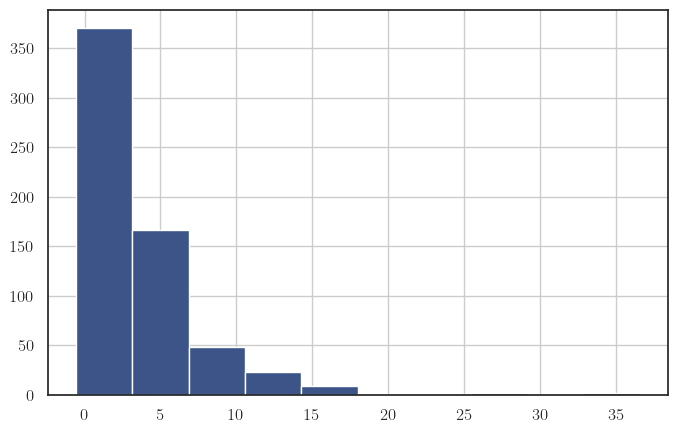

In [33]:
df_twosided["offer_time_1"].hist()

In [34]:
slient_signaling = smf.ols(formula='valuation ~ offer_time_1', data=df_twosided).fit()

print(slient_signaling.summary())

                            OLS Regression Results                            
Dep. Variable:              valuation   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.02709
Date:                Mon, 16 Jun 2025   Prob (F-statistic):              0.869
Time:                        14:17:01   Log-Likelihood:                -2627.3
No. Observations:                 622   AIC:                             5259.
Df Residuals:                     620   BIC:                             5268.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       27.3726      0.913     29.965   

In [35]:

pystout(models=[first_mover_advantage, slient_signaling],
file='regression.tex',
addnotes=['Here is a little note','And another one'],
digits=2,
endog_names=['Split Gains from Trade', "Valuation"],
varlabels={'const':'Constant','first_offer':'First Offer', 'offer_time_1':'First Offer Time'},
modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_69089/17651594.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


## Time Preferences

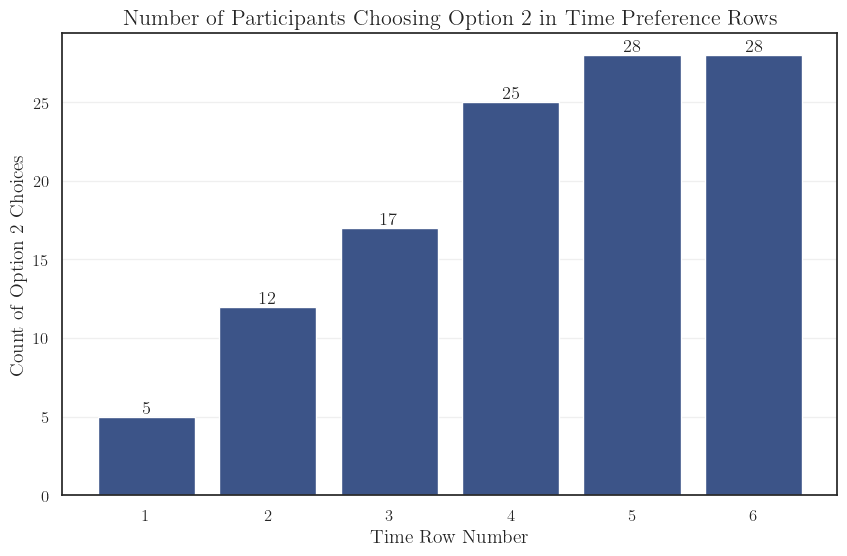

In [5]:
df_round33 = df[df['round'] == 33]

# Calculate counts of value 2 for each time_row column
counts = []
for i in range(1, 7):
    col = f'time_row_{i}'
    count = (df_round33[col] == 2).sum()
    counts.append(count)

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, 7), counts)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

# Customize the plot
plt.title('Number of Participants Choosing Option 2 in Time Preference Rows')
plt.xlabel('Time Row Number')
plt.ylabel('Count of Option 2 Choices')
plt.xticks(range(1, 7))
plt.grid(axis='y', alpha=0.3)

# Show the plot
plt.show()

In [23]:
# Initialize list to store violations
violations = []

# Check each participant's choices
for _, row in df_round33.iterrows():
    choices = [row[f'time_row_{i}'] for i in range(1, 7)]
    switched_to_2 = False
    violation = False
    
    for i, choice in enumerate(choices):
        if choice == 2:
            switched_to_2 = True
        elif choice == 1 and switched_to_2:
            violation = True
            violations.append({
                'participant_id': row['participant_id'],
                'violation_at_row': i + 1,
                'choices': choices
            })
            break

# Create DataFrame of violations
violations_df = pd.DataFrame(violations)

In [24]:
violations_df

""


## Main Plot

<module 'matplotlib.pyplot' from '/Users/nicolasroever/opt/anaconda3/envs/bargaining_analysis/lib/python3.12/site-packages/matplotlib/pyplot.py'>

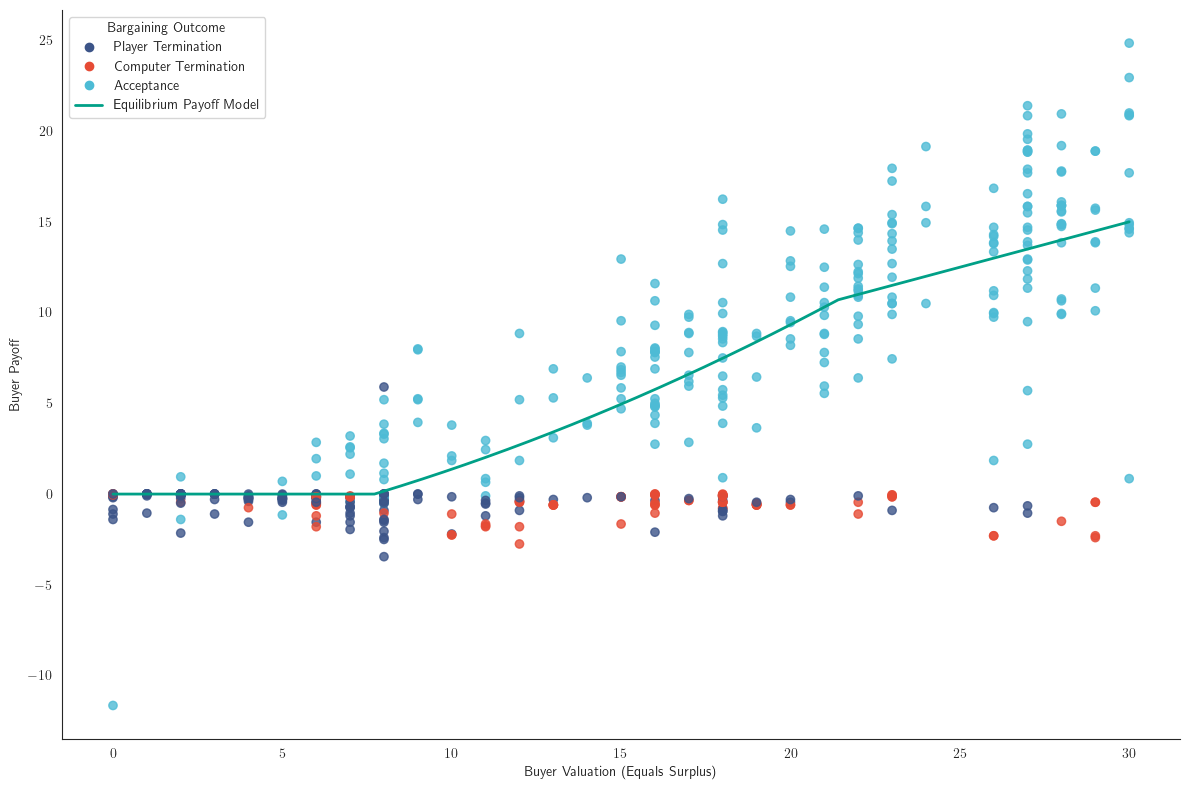

In [13]:
plot_T4_buyer_payoff_vs_valuation(df, COLOR_SCHEME)

## First Mover Seller Predictions

In [14]:
df_regression = df.dropna(subset=["first_offer"])


model_1 = smf.ols(formula='first_offer ~ C(participant_role)', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            first_offer   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     8.813
Date:                Wed, 11 Jun 2025   Prob (F-statistic):            0.00308
Time:                        16:25:37   Log-Likelihood:                -609.63
No. Observations:                 846   AIC:                             1223.
Df Residuals:                     844   BIC:                             1233.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [15]:
df["efficiency"].mean()

np.float64(0.5031315240083507)

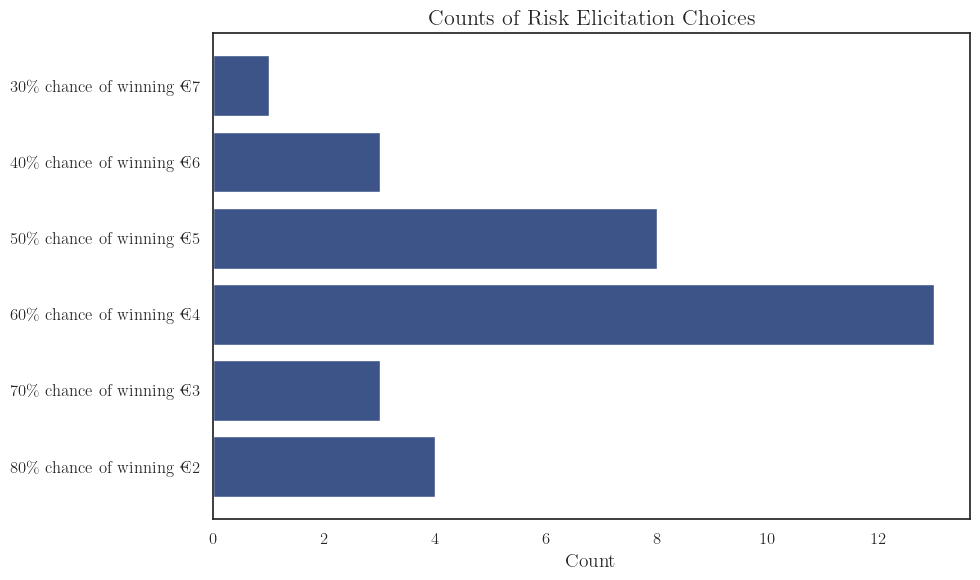

In [12]:
# (re)compute your counts
risk_labels = [
    r"80\% chance of winning €2",
    r"70\% chance of winning €3",
    r"60\% chance of winning €4",
    r"50\% chance of winning €5",
    r"40\% chance of winning €6",
    r"30\% chance of winning €7"
]
risk_counts = df_round33["risk_elicitation_choice"] \
    .value_counts() \
    .reindex(range(1, 7), fill_value=0)

# horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(risk_labels, risk_counts.values)
plt.xlabel('Count')
plt.title('Counts of Risk Elicitation Choices')
plt.tight_layout()
plt.show()

<Axes: >

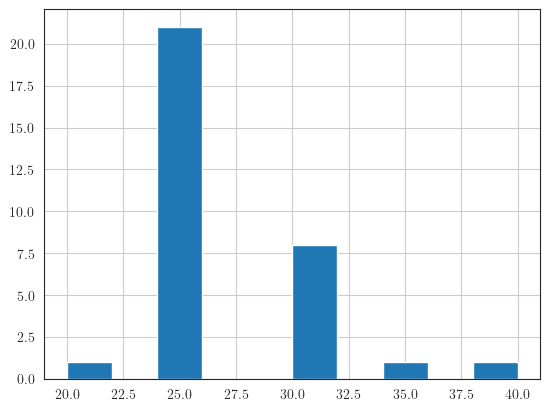

In [16]:
def plot_ultimatum_offer_histogram(df):
    """
    Plots a histogram of ultimatum offers for round 33.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.

    Returns:
    None
    """
    df[df["round"] == 33]["ultimatum_offer"].hist()
    plt.xlabel('Money to Keep in Euros')
    plt.ylabel('Frequency')
    plt.title('Histogram of Ultimatum Offers in Round 33')
    plt.show()

# Example usage:
# plot_ultimatum_offer_histogram(df)

<Axes: >

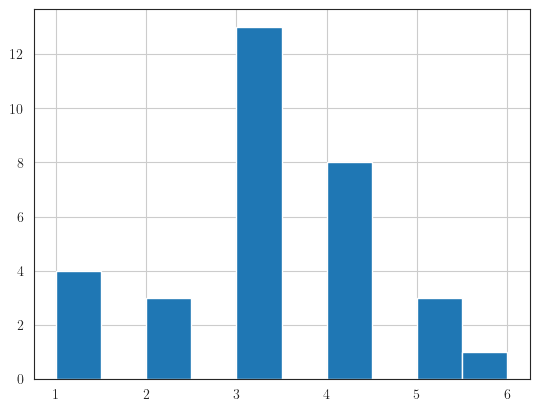

In [17]:
df[df["round"] == 33]["risk_elicitation_choice"].hist()

In [8]:
df_regression = df.dropna(subset=["efficiency"])


model_1 = smf.ols(formula='efficiency ~ ultimatum_indicator', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.593
Date:                Wed, 11 Jun 2025   Prob (F-statistic):              0.207
Time:                        16:22:48   Log-Likelihood:                -694.49
No. Observations:                 958   AIC:                             1393.
Df Residuals:                     956   BIC:                             1403.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5333    

In [18]:
df_regression = df.dropna(subset=["efficiency"])


model_1 = smf.ols(formula='efficiency ~ risk_elicitation_choice', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             efficiency   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5225
Date:                Wed, 11 Jun 2025   Prob (F-statistic):              0.470
Time:                        16:25:57   Log-Likelihood:                -695.03
No. Observations:                 958   AIC:                             1394.
Df Residuals:                     956   BIC:                             1404.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Old Stuff

In [5]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/DataCollection130052025/all_apps_wide-2025-05-14.csv")



In [6]:
df_two_sided = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/two_sided_without_TA.pkl")

## First Mover Regression

<Axes: >

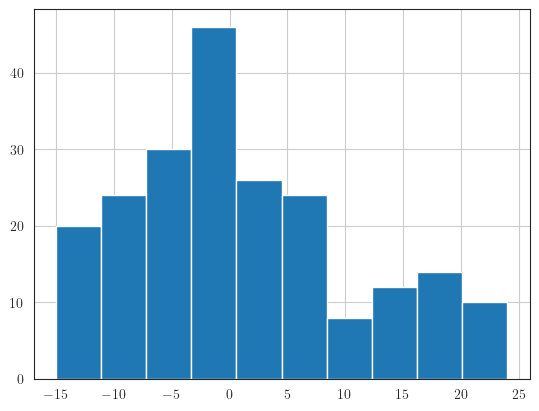

In [7]:
df_two_sided["gains_from_trade"].hist()

In [8]:
df_regression = df_two_sided.dropna(subset=["payoff", "first_offer"])

df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce') 

model_1 = smf.ols(formula='payoff ~ first_offer', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                 0.0002500
Date:                Wed, 11 Jun 2025   Prob (F-statistic):              0.987
Time:                        15:31:55   Log-Likelihood:                -553.18
No. Observations:                 188   AIC:                             1110.
Df Residuals:                     186   BIC:                             1117.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.1277      0.476      4.472      

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/536089823.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce')


In [9]:
df_regression = df_two_sided[df_two_sided["split_gains_from_trade"] > 0]

df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce') 

df_regression.dropna(subset=["split_gains_from_trade", "first_offer"], inplace=True)

model_2 = smf.ols(formula='split_gains_from_trade ~ first_offer', data=df_regression).fit()

# 4. Examine the results
print(model_2.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.047
Model:                                OLS   Adj. R-squared:                  0.030
Method:                     Least Squares   F-statistic:                     2.781
Date:                    Wed, 11 Jun 2025   Prob (F-statistic):              0.101
Time:                            15:31:55   Log-Likelihood:                -59.368
No. Observations:                      59   AIC:                             122.7
Df Residuals:                          57   BIC:                             126.9
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept 

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/3190619071.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce')
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/3190619071.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression.dropna(subset=["split_gains_from_trade", "first_offer"], inplace=True)


In [10]:

model_3 = smf.ols(formula='bargaining_time_full_sec ~ valuation', data=df_two_sided).fit()

print(model_3.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.007
Model:                                  OLS   Adj. R-squared:                  0.003
Method:                       Least Squares   F-statistic:                     1.598
Date:                      Wed, 11 Jun 2025   Prob (F-statistic):              0.208
Time:                              15:31:55   Log-Likelihood:                -4685.6
No. Observations:                       214   AIC:                             9375.
Df Residuals:                           212   BIC:                             9382.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [11]:
pystout(models=[model_1, model_2],
        file='test_table.tex',
        addnotes=['Here is a little note','And another one'],
        digits=2,
        endog_names=['Payoff','Split Gains from Trade'],
        varlabels={'const':'Constant','first_offer':'First Offer'},
        modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
        )


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_10250/4137003316.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='valuation', y='gains_from_trade', data=df_buyers, alpha=0.7)

# Customize the plot
plt.title('Scatterplot of Valuation vs. Gains from Trade')
plt.xlabel('Valuation')
plt.ylabel('Gains from Trade')

# Show the plot
plt.show()


NameError: name 'df_buyers' is not defined

<Figure size 1000x600 with 0 Axes>

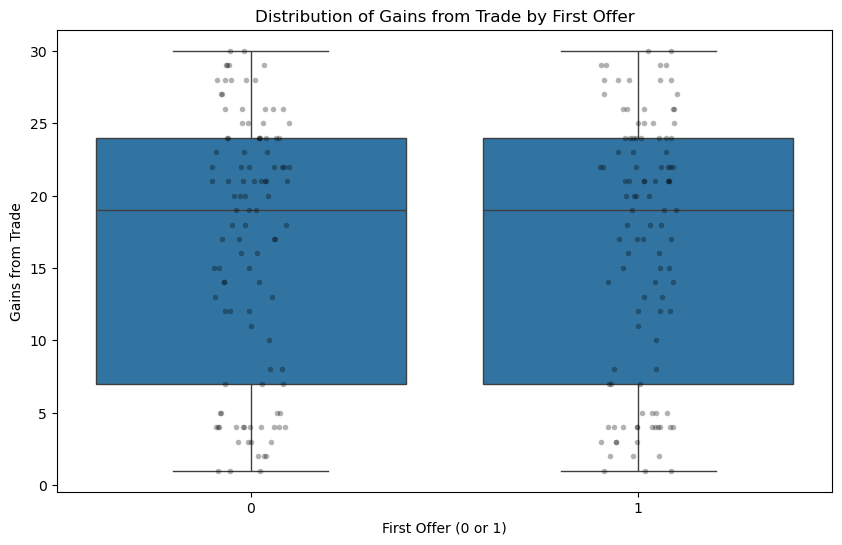

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='first_offer', y='gains_from_trade', data=df)

# Customize the plot
plt.title('Distribution of Gains from Trade by First Offer')
plt.xlabel('First Offer (0 or 1)')
plt.ylabel('Gains from Trade')

# Add individual data points
sns.stripplot(x='first_offer', y='gains_from_trade', data=df, 
              color='black', alpha=0.3, size=4)

# Save the plot
plt.show()

In [ ]:
df = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/one_sided_with_TA.pkl")
df_buyers = df[(df["participant_role"] == "Buyer")]

In [3]:
# Define the piecewise function
def equilibrium_payoff(x, c=0.05, r=0.01):
    if x <= 7.72:
        return 0
    elif x >= 21.40:
        return x/2
    else:
        b = x
        return ((r*b + 2*c)/(r*21.40 + 2*c)) * (b/2 + c/r) - c/r


In [4]:
# Generate x values for the theoretical line
x_values = np.linspace(0, 30, 1000)
y_values = [equilibrium_payoff(x) for x in x_values]


COLOR_SCHEME=["#3c5488","#00a087", "#e64b35", "#4dbbd5",  "#f39b7f", ]
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
sns.set_style("white")
sns.set_palette(COLOR_SCHEME)


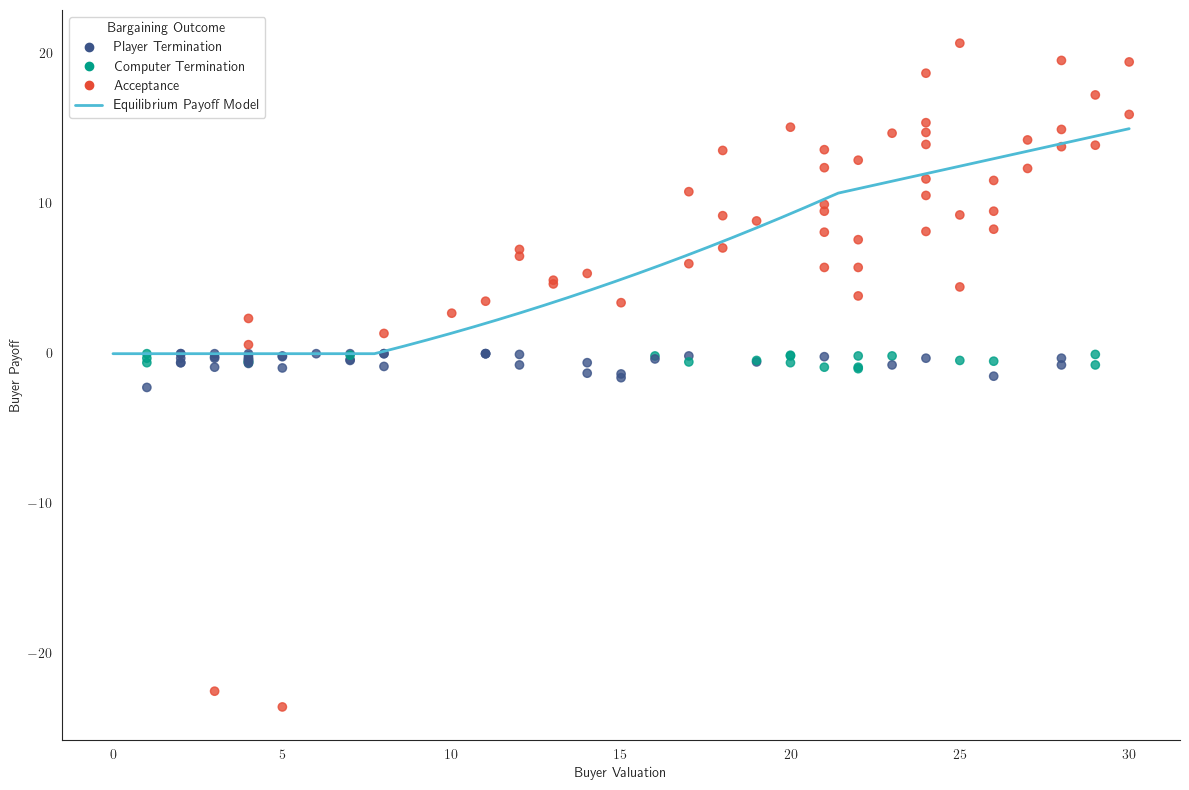

In [9]:

# Define your color scheme
COLOR_SCHEME = ["#3c5488", "#00a087", "#e64b35", "#4dbbd5", "#f39b7f"]

# Define a mapping from outcome labels to colors
outcome_color_map = {
    'Player': COLOR_SCHEME[0],               # Player Termination
    'Random_Termination': COLOR_SCHEME[1],   # Computer Termination
    'acceptance': COLOR_SCHEME[2],           # Highlight Acceptance
}

# Assign color values based on the outcome
colors = df_buyers['bargaining_outcome'].map(outcome_color_map)

plt.figure(figsize=(12, 8))

# Plot the theoretical line
plt.plot(x_values, y_values, color=COLOR_SCHEME[3], linewidth=2, label='Equilibrium Payoff Model')

# Add the scatter plot with custom colors
scatter = plt.scatter(
    df_buyers['valuation'],
    df_buyers['payoff'],
    c=colors,
    alpha=0.8
)

plt.xlabel('Buyer Valuation (Equals Surplus) ')
plt.ylabel('Buyer Payoff')

# Create custom legend
import matplotlib.lines as mlines
legend_elements = [
    mlines.Line2D([], [], color=COLOR_SCHEME[0], marker='o', linestyle='None', label='Player Termination'),
    mlines.Line2D([], [], color=COLOR_SCHEME[1], marker='o', linestyle='None', label='Computer Termination'),
    mlines.Line2D([], [], color=COLOR_SCHEME[2], marker='o', linestyle='None', label='Acceptance'),
    mlines.Line2D([], [], color=COLOR_SCHEME[3], linewidth=2, label='Equilibrium Payoff Model')
]

plt.legend(handles=legend_elements, title="Bargaining Outcome")

sns.despine()
plt.tight_layout()
plt.show()
